# Sickle-cell detection — the final two-stage pipeline · IBEX / A100

**Stage 1 finds the cells. Stage 2 names them.** A fine-tuned **YOLO11m-seg** instance segmenter
locates every red blood cell in a whole smear as a single `RBC` class; a fine-tuned
**InceptionV3** then classifies each returned crop as `circular` (healthy) or `elongated`
(sickle). One notebook, five code cells, one folder of artefacts.

Tuned for **one A100 on IBEX**, with `Sickle_Cell_Dataset_1.zip` as the only data input.

| cell | what it does | headline output |
|---|---|---|
| **1 · setup** | IBEX env, GPU tier, shared config, run log | `state.json`, `checkpoints.json` |
| **2 · data** | unpack the zip · pixel-GT seed labels · measured cell size · SAM pseudo-labels · both splits | `seg_ds/`, `crop_splits.csv` |
| **3 · segmentation** | fine-tune YOLO-seg, grade it on held-out pixel-GT smears | `weights/yolo_seg_rbc.pt`, `F1@IoU0.5` |
| **4 · classification** | two-phase fine-tune of InceptionV3, grade it on held-out crops | `weights/cls_inceptionv3.pt`, macro-F1 |
| **5 · end-to-end** | smear in → annotated smear + sickle fraction out | `final_results.json`, `final_summary.csv` |

### What "tuned for A100" actually changed

| | A100 | anything smaller |
|---|---|---|
| segmenter | `yolo11m-seg.pt` | `yolo11s-seg.pt` |
| SAM pseudo-labeller | `vit_h` | `vit_b` |
| pseudo-label budget | up to 1 100 smears | up to 150 |
| autocast | **bf16**, no GradScaler | fp16 + scaler |
| matmul | TF32 + `matmul_precision('high')` | — |
| YOLO batch | `-1` AutoBatch (DDP across every visible GPU) | same |
| image cache | `'ram'` | off |

Capacity is **no longer tier-independent** — that was the right call for the shoot-outs in
`00`–`16`, where A100 and T4 rows had to be comparable, and it is the wrong call here. A weaker
card still runs this notebook, but cell 1 prints a loud warning and the result files record which
tier produced them.

Everything else that touches IBEX: HF / torch / Ultralytics / matplotlib caches are redirected to
`/ibex/user/$USER` **before** `import torch`, so the small `$HOME` quota is never touched;
dataloader workers follow `$SLURM_CPUS_PER_TASK` instead of a hard-coded 8; Ultralytics telemetry
and sync are switched off for offline compute nodes.

### Three rules the whole notebook obeys

1. **Split by smear, never by cell.** Both stages group their splits by source smear, so no
   cell from a training smear can appear in validation or test.
2. **Grade only on real pixel ground truth.** SAM is used as a *labelling tool* to enlarge the
   training set, and the segmenter is never scored on a SAM-derived label — that would be
   circular. Held-out smears with hand-made masks are the only benchmark.
3. **Macro-F1, not accuracy.** The `elongated` class is the majority, so accuracy flatters
   every model. Model selection and reporting both use macro-F1.

### Running it

```bash
sbatch run_ibex.sh
```

Or cell by cell. Either way every stage is **rerun-safe** — existing weights are loaded instead of
retrained, finished SAM labels are skipped, and an already-unpacked dataset is not re-extracted.
Expect roughly **2–4 h on one A100**, dominated by SAM `vit_h` pseudo-labelling; set
`CFG['use_sam_pseudo'] = False` for a ~40 min run on the 78 pixel-GT smears alone.

> **The confound, stated up front.** Uganda contributes no healthy cells, so the `circular`
> class is 100 % Cuban. Country and label are partially entangled: a network can score well by
> learning *"Cuban stain and optics ⇒ circular"* without ever learning cell shape. Cell 4 prints
> a per-population recall breakdown so that stays visible rather than hidden inside one number.


In [2]:
# ═════════════════════════════════════════════════════════════════════════════
#  1 · SETUP  —  IBEX/A100 environment, shared config, run log
#
#  This notebook TARGETS one machine: a single A100 on IBEX, data delivered as
#  Sickle_Cell_Dataset_1.zip. It still runs on a T4 or on CPU, but with reduced
#  capacity, and it says so loudly instead of shrinking the model silently.
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, re, glob, json, math, time, random, shutil, zipfile, warnings, subprocess

# ── IBEX first: every cache off the small $HOME quota, BEFORE torch/mpl import ──
#  $HOME on IBEX is a few GB. torch hub weights, HF snapshots, the Ultralytics
#  settings file and matplotlib's font cache all default there and will fill it.
ON_SLURM = bool(os.environ.get('SLURM_JOB_ID'))
IS_IBEX = bool(ON_SLURM or os.path.isdir('/ibex'))
SCRATCH = (os.environ.get('SCD_SCRATCH')
           or next((d for d in (f"/ibex/user/{os.environ.get('USER', '')}",
                                f"/ibex/scratch/user/{os.environ.get('USER', '')}",
                                f"/ibex/ai/home/{os.environ.get('USER', '')}")
                    if os.path.isdir(d)), '')
           or os.environ.get('SCD_RUNS_DIR', '')
           or os.getcwd())
if IS_IBEX:
    for _var, _sub in (('HF_HOME', 'hf'), ('TORCH_HOME', 'torch'), ('XDG_CACHE_HOME', 'cache'),
                       ('YOLO_CONFIG_DIR', 'ultralytics'), ('MPLCONFIGDIR', 'mpl')):
        os.environ.setdefault(_var, os.path.join(SCRATCH, _sub))
        os.makedirs(os.environ[_var], exist_ok=True)
    os.environ.setdefault('MPLBACKEND', 'Agg')            # headless compute node
    os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')


def _has(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False


def _refresh_import_path():
    '''make what pip just installed visible to THIS interpreter, without a kernel restart'''
    import site, sysconfig, importlib
    cands = [sysconfig.get_path('purelib'), sysconfig.get_path('platlib')]
    for get in (site.getusersitepackages, site.getsitepackages):
        try:
            got = get()
            cands += [got] if isinstance(got, str) else list(got)
        except Exception:
            pass
    for d in cands:
        if d and os.path.isdir(d) and d not in sys.path:
            sys.path.append(d)                       # append: never shadow the image's own
    importlib.invalidate_caches()
    sys.modules.pop('pkg_resources', None)           # its metadata cache is now stale


def _ensure(*pkgs):
    '''pip-install only what is genuinely missing -- IBEX compute nodes are often OFFLINE.

    No -U: these images pin a whole CUDA/numpy stack, and upgrading a transitive dep to
    satisfy a new package is how you break the rest of the session. Pre-pull everything on
    a login node (see run_ibex.sh) so this is a no-op inside the job.'''
    miss = [spec for mod, spec in pkgs if not _has(mod)]
    if not miss:
        return
    print('installing:', *miss)
    for extra in ([], ['--user']):                   # plain first; --user if it stayed invisible
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + extra + list(miss),
                       capture_output=True, text=True)
        _refresh_import_path()
        miss = [spec for mod, spec in pkgs if not _has(mod)]
        if not miss:
            return
    raise ImportError('could not import after installing: ' + ', '.join(miss) +
                      '\n  If pip succeeded, restart the kernel and re-run.'
                      '\n  On an offline compute node, install them from a login node first.')


_ensure(('cv2', 'opencv-python-headless'), ('ultralytics', 'ultralytics'),
        ('sklearn', 'scikit-learn'))

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
import torchvision.models as tvm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PLATFORM = ('colab' if 'google.colab' in sys.modules else 'ibex' if IS_IBEX else 'local')

# ── which GPU? ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEV, NGPU = 'cuda', torch.cuda.device_count()
    GPU = torch.cuda.get_device_name(0)
    CAP = torch.cuda.get_device_capability(0)
    VRAM = torch.cuda.get_device_properties(0).total_memory / 2 ** 30
else:
    DEV, NGPU, GPU, CAP, VRAM = 'cpu', 0, 'cpu', (0, 0), 0.0

TIER = 'a100' if (CAP[0] >= 8 and VRAM >= 30) else ('t4' if DEV == 'cuda' else 'cpu')

# A100: bf16 has fp32's exponent range, so no GradScaler and no overflow; TF32 gives ~2x on
# every fp32 matmul and conv for free. fp16 (T4) still needs loss scaling.
AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and DEV == 'cuda'
if CAP[0] >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True                 # fixed input sizes -> autotune wins

# ── dataloader width follows the ALLOCATION, not a hard-coded guess ───────────
#  Asking for 8 workers inside `--cpus-per-task=4` oversubscribes the cgroup and runs
#  slower than 3 workers would. SLURM tells us the real number, so use it.
_CPUS = int(os.environ.get('SLURM_CPUS_PER_TASK') or os.environ.get('SLURM_JOB_CPUS_PER_NODE')
            or os.cpu_count() or 4)
WORKERS = min(_CPUS - 1, 16) if DEV == 'cuda' else 0
os.environ.setdefault('OMP_NUM_THREADS', str(max(1, _CPUS // max(WORKERS, 1))))

# ── CAPACITY knobs: tuned for the A100 this notebook targets ─────────────────
#  A weaker card gets the smaller variants so the notebook still completes, but the two
#  are NOT comparable and every result file records which one produced it.
CAPACITY = {
    'a100': dict(yolo_weights='yolo11m-seg.pt',       # 'yolo26m-seg.pt' w/ ultralytics >= 8.4
                 sam_variant='vit_h',                 # best pseudo-labels; ~3x vit_b's cost
                 sam_max={'cuba_full': 400, 'uganda_clean': 500, 'uganda_neg': 200}),
    'small': dict(yolo_weights='yolo11s-seg.pt',
                  sam_variant='vit_b',
                  sam_max={'cuba_full': 60, 'uganda_clean': 60, 'uganda_neg': 30}),
}['a100' if TIER == 'a100' else 'small']

# ── THROUGHPUT knobs: pure speed, no effect on the result ────────────────────
THROUGHPUT = {
    'a100': dict(cls_batch=64, prefetch=6, yolo_cache='ram', sam_points_bulk=32,
                 sam_qc_smears=30),
    't4':   dict(cls_batch=32, prefetch=2, yolo_cache=False, sam_points_bulk=24,
                 sam_qc_smears=20),
    'cpu':  dict(cls_batch=8, prefetch=2, yolo_cache=False, sam_points_bulk=16,
                 sam_qc_smears=4),
}[TIER]

CFG = {
    # --- the dataset IS the zip; everything else is derived from it ---------------------------
    'data_zip':    os.environ.get('SCD_DATA_ZIP', ''),   # explicit path wins
    'zip_names':   ['Sickle_Cell_Dataset_1.zip', 'Sickle_Cell_Dataset.zip'],
    'zip_hints':   [os.getcwd(), os.path.dirname(os.getcwd()),
                    os.path.expanduser('~/Downloads/scd_pipeline'),
                    os.path.expanduser('~/Downloads'), os.path.expanduser('~/Desktop'),
                    os.path.expanduser('~/scratch'), os.path.expanduser('~/data'), SCRATCH,
                    f"/ibex/user/{os.environ.get('USER', '')}",
                    '/content', '/content/drive/MyDrive/SRSI_Final',
                    '/content/drive/MyDrive/SRSI SCD project'],
    # where the zip is unpacked. Persistent by default: $TMPDIR is node-local and wiped at
    # the end of the job, which would break the absolute crop paths a later job reads back.
    'extract_dir': os.environ.get('SCD_EXTRACT_DIR', ''),
    'data_root':   os.environ.get('SCD_DATA_ROOT', ''),  # skips the zip entirely if complete
    'runs_dir':    os.environ.get('SCD_RUNS_DIR', ''),

    # --- stage 1: YOLO instance segmentation -------------------------------------------------
    'yolo_weights':  CAPACITY['yolo_weights'],
    'yolo_imgsz':    1024,               # auto-falls back to 640 px on CUDA OOM
    'yolo_epochs':   100,
    'yolo_patience': 20,
    'yolo_conf':     0.15,               # benchmark confidence floor
    'seg_val_frac':  0.20,               # held-out SMEARS
    'eval_side':     1024,               # long side the segmenter is benchmarked at

    # --- training-label expansion (SAM used as a LABELLER, never as a graded model) -----------
    'use_sam_pseudo': True,              # False -> train on the 78 pixel-GT smears only
    'sam_variant':    CAPACITY['sam_variant'],
    'sam_max':        CAPACITY['sam_max'],
    'sam_side':       1024,

    # --- stage 2: InceptionV3 classification -------------------------------------------------
    'cls_name':    'inceptionv3',
    'cls_size':    299,                  # InceptionV3's native input
    'epochs_head': 8,                    # phase 1 -- frozen backbone, new head only
    'epochs_ft':   12,                   # phase 2 -- top blocks unfrozen at 10x lower LR
    'lr_head':     1e-3,
    'lr_ft':       1e-4,
    'cuba_block':  10,                   # Cuba crops carry no smear ID -> contiguous ID blocks
    'val_frac':    0.15,
    'test_frac':   0.15,

    'classes': ['circular', 'elongated'],   # 0 = circular (normal), 1 = elongated (sickle)
    'workers': WORKERS,
    **THROUGHPUT,
}

# ── output root: /ibex scratch under SLURM, Drive on Colab, cwd otherwise ─────
_drive = next((h for h in ('/content/drive/MyDrive/SRSI_Final',
                           '/content/drive/MyDrive/SRSI SCD project') if os.path.isdir(h)), '')
if not CFG['runs_dir']:
    CFG['runs_dir'] = os.path.join(SCRATCH if IS_IBEX else (_drive or os.getcwd()),
                                   'runs_two_stage')
if not CFG['extract_dir']:
    CFG['extract_dir'] = os.path.join(SCRATCH if IS_IBEX else
                                      os.path.dirname(os.path.abspath(CFG['runs_dir'])),
                                      'scd_data')

FIG = os.path.join(CFG['runs_dir'], 'figures')
WTS = os.path.join(CFG['runs_dir'], 'weights')
TAB = os.path.join(CFG['runs_dir'], 'tables')
BENCH = os.path.join(CFG['runs_dir'], 'seg_bench')
CBENCH = os.path.join(CFG['runs_dir'], 'cls_bench')
for _d in (FIG, WTS, TAB, BENCH, CBENCH):
    os.makedirs(_d, exist_ok=True)

STATE_PATH = os.path.join(CFG['runs_dir'], 'state.json')


def read_state():
    return json.load(open(STATE_PATH)) if os.path.exists(STATE_PATH) else {}


def save_state(**kw):
    st = read_state()
    st.update(kw)
    json.dump(st, open(STATE_PATH, 'w'), indent=2, default=str)
    return st


def need(*keys, cell='2 · DATA'):
    '''fetch values an earlier cell resolved, with an error that says which cell writes them'''
    st = read_state()
    miss = [k for k in keys if k not in st]
    if miss:
        raise RuntimeError(f'missing {miss} in {STATE_PATH}\n  -> run cell {cell} first')
    out = [st[k] for k in keys]
    return out[0] if len(out) == 1 else out


# ── shared utilities ─────────────────────────────────────────────────────────
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')   # dataset has mixed-case .JPG


def imgs_in(d):
    '''image files sitting directly inside d (skips macOS ._ stubs)'''
    if not d or not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in sorted(os.listdir(d))
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]


def load_rgb(path, long_side=None):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if long_side:
        s = long_side / max(im.shape[:2])
        if s < 1:
            im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im


def savefig(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p, dpi=150, bbox_inches='tight')
    return p


def mask_to_polys(mask, min_area=25):
    '''binary mask -> list of NORMALISED YOLO polygons [x1,y1,x2,y2,...]'''
    H, W = mask.shape
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        c = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True)
        if len(c) < 3:
            continue
        p = c.reshape(-1, 2).astype(np.float32)
        p[:, 0] /= W
        p[:, 1] /= H
        polys.append(np.clip(p, 0, 1).reshape(-1))
    return polys


def read_polys(label_txt, W, H):
    '''YOLO-seg label file -> list of per-instance pixel polygons at (W, H)'''
    out = []
    for line in open(label_txt):
        v = line.split()[1:]
        if len(v) < 6:
            continue
        out.append((np.array(v, np.float32).reshape(-1, 2) * [W, H]).astype(np.int32))
    return out


def autocast_ctx():
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEV == 'cuda'))


def make_scaler():
    '''bf16 (A100) needs no loss scaling; fp16 (T4) does. torch>=2.4 moved the class.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_SCALER)


def free_gpu(*names):
    import gc
    for n in names:
        globals().pop(n, None)
    gc.collect()
    if DEV == 'cuda':
        torch.cuda.empty_cache()


# ── the run log: one appended record per stage, so a re-run sits next to the run
#    it replaced instead of erasing it. Atomic write -- stages can finish at once.
CKPT_LOG = os.path.join(CFG['runs_dir'], 'checkpoints.json')


def _ckpt_art(p):
    '''one artefact -> exists / size / mtime. Directories are summarised, not listed.'''
    p = str(p)
    if not os.path.exists(p):
        return {'path': p, 'exists': False}
    if os.path.isdir(p):
        fs = [os.path.join(r, f) for r, _, ns in os.walk(p) for f in ns]
        mt = max([os.path.getmtime(f) for f in fs] or [os.path.getmtime(p)])
        return {'path': p, 'exists': True, 'kind': 'dir', 'files': len(fs),
                'mb': round(sum(os.path.getsize(f) for f in fs) / 2 ** 20, 2),
                'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(mt))}
    return {'path': p, 'exists': True, 'kind': 'file',
            'mb': round(os.path.getsize(p) / 2 ** 20, 3),
            'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))}


def _ckpt_val(v):
    '''keep the log json-safe: numbers stay numbers, NaN/inf become null, the rest becomes text'''
    if v is None or isinstance(v, (bool, str)):
        return v
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    return None if (math.isnan(f) or math.isinf(f)) else round(f, 6)


def _ckpt_minutes():
    try:
        import psutil
        return round((time.time() - psutil.Process(os.getpid()).create_time()) / 60, 2)
    except Exception:
        return None


def checkpoint(stage, produced=None, metrics=None, status='ok', notes=''):
    '''record that `stage` finished. `produced` = {label: path}; each one is stat'ed, not
    assumed -- if an artefact is gone the record says MISSING ARTEFACTS and names it.'''
    nb = f'17_final_pipeline/{stage}'
    arts = {k: _ckpt_art(v) for k, v in (produced or {}).items() if v}
    missing = sorted(k for k, a in arts.items() if not a['exists'])
    rec = {'nb': nb, 'status': 'MISSING ARTEFACTS' if missing else status,
           'finished': time.strftime('%Y-%m-%d %H:%M:%S'), 'minutes': _ckpt_minutes(),
           'platform': PLATFORM, 'tier': TIER, 'gpu': GPU, 'n_gpu': NGPU,
           'vram_gb': round(VRAM, 1), 'cpus': _CPUS, 'workers': WORKERS,
           'torch': torch.__version__, 'seed': SEED,
           'slurm_job': os.environ.get('SLURM_JOB_ID', ''), 'runs_dir': CFG['runs_dir'],
           'metrics': {k: _ckpt_val(v) for k, v in (metrics or {}).items()},
           'artefacts': arts, 'missing': missing, 'notes': notes,
           'state_keys': sorted(read_state())}

    log = []
    if os.path.exists(CKPT_LOG):
        try:
            log = [r for r in json.load(open(CKPT_LOG)) if isinstance(r, dict)]
        except Exception:
            shutil.copy(CKPT_LOG, CKPT_LOG + '.corrupt')
            print(f'!! {CKPT_LOG} was unreadable -- copied to .corrupt, starting a new log')
    log.append(rec)
    tmp = f'{CKPT_LOG}.{os.getpid()}.tmp'
    json.dump(log, open(tmp, 'w'), indent=2, default=str)
    os.replace(tmp, CKPT_LOG)

    print('\n' + '=' * 78)
    print(f'  CHECKPOINT  {nb}   [{rec["status"]}]'
          + (f'   {rec["minutes"]:.1f} min' if rec['minutes'] else ''))
    print('=' * 78)
    for k, a in arts.items():
        print(f'  {"ok  " if a["exists"] else "MISS"}  {k:<20s} {a.get("mb", 0):>9.2f} MB  '
              f'{a["path"]}')
    for k, v in rec['metrics'].items():
        print(f'  metric  {k:<22s} {v}')
    return rec


CLR = {'circular': '#2E86C1', 'elongated': '#C0392B'}
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'platform   {PLATFORM}' + (f"  | SLURM job {os.environ['SLURM_JOB_ID']}"
                                  f" | {os.environ.get('SLURM_JOB_PARTITION', '?')}"
                                  if ON_SLURM else ''))
print(f'device     {GPU} x{NGPU} | {VRAM:.0f} GB | sm_{CAP[0]}{CAP[1]}  ->  tier {TIER!r}, '
      f'AMP {str(AMP_DTYPE).split(".")[-1]}' + (', TF32 on' if CAP[0] >= 8 else ''))
print(f'cpus       {_CPUS} allocated -> {WORKERS} dataloader workers')
print(f'torch      {torch.__version__} | torchvision {torchvision.__version__} | cv2 {cv2.__version__}')
print(f'pipeline   {CFG["yolo_weights"]}  ->  {CFG["cls_name"]}   '
      f'(SAM {CFG["sam_variant"]} for pseudo-labels)')
print(f'runs_dir   {CFG["runs_dir"]}')
print(f'extract    {CFG["extract_dir"]}')
if IS_IBEX:
    print(f'caches     HF/torch/ultralytics/mpl -> {SCRATCH}   ($HOME quota untouched)')

if TIER != 'a100':
    print('\n' + '!' * 78)
    print('!! This notebook is tuned for a single A100. This is a', TIER.upper(), 'tier device,')
    print('!! so it drops to', CAPACITY['yolo_weights'], '+ SAM', CAPACITY['sam_variant'],
          'and a smaller pseudo-label budget.')
    print('!! It will finish, but its numbers are NOT comparable with an A100 run.')
    if DEV == 'cpu':
        print('!! NO GPU AT ALL -- IBEX: srun --gres=gpu:a100:1 --cpus-per-task=16 --mem=64G')
    print('!' * 78)

platform   ibex  | SLURM job 49993699 | gpu
device     NVIDIA A100-SXM4-80GB x1 | 79 GB | sm_80  ->  tier 'a100', AMP bfloat16, TF32 on
cpus       8 allocated -> 7 dataloader workers
torch      2.1.2 | torchvision 0.16.2 | cv2 4.11.0
pipeline   yolo11m-seg.pt  ->  inceptionv3   (SAM vit_h for pseudo-labels)
runs_dir   /ibex/user/bahajao/runs_two_stage
extract    /ibex/user/bahajao/scd_data
caches     HF/torch/ultralytics/mpl -> /ibex/user/bahajao   ($HOME quota untouched)


## 2 · Data — the zip is the dataset

One 344 MB archive is the whole input. This cell finds `Sickle_Cell_Dataset_1.zip`, unpacks it
**once** to scratch, turns Cuba's hand-made pixel masks into YOLO-format seed labels, **measures
how big a real red blood cell actually is** so every later blob filter is anchored to a
measurement rather than a guess, enlarges the training set with audited SAM pseudo-labels, and
writes the two splits the later cells read back from disk.

| override | effect |
|---|---|
| `SCD_DATA_ZIP=/path/to.zip` | use this archive instead of searching |
| `SCD_EXTRACT_DIR=/path` | unpack here (default `/ibex/user/$USER/scd_data`) |
| `SCD_DATA_ROOT=/path` | skip the zip entirely — only if the tree is already complete |

The extract dir is **persistent by default, not `$TMPDIR`**: node-local scratch is wiped when the
job ends, which would strand the absolute crop paths a later job reads back. Point
`SCD_EXTRACT_DIR` at `$TMPDIR` if you want one fully self-contained job — cell 4 re-bases the crop
paths onto the current `data_root`, so that stays safe.

Set `CFG['use_sam_pseudo'] = False` in cell 1 to skip the pseudo-labelling pass and train on the
78 pixel-GT smears alone — much faster, no SAM download, weaker detector.


dataset zip -> /ibex/user/bahajao/sickle-cell/Sickle_Cell_Dataset_for_colab.zip   (323 MB on disk)
already unpacked -> /ibex/user/bahajao/scd_data   (delete it to force a fresh extract)
  7/7 components under /ibex/user/bahajao/scd_data

data_root -> /ibex/user/bahajao/scd_data/Sickle_Cell_Dataset 

                   component                                     path    n
           Cuba  full smears                         Cuba/full_smears   80
        Cuba  cells_circular                      Cuba/cells_circular  202
       Cuba  cells_elongated                     Cuba/cells_elongated  211
        Cuba  GT mask smears                         _supplementary/*   79
Uganda positive_sickle_clean Uganda/full_smears/positive_sickle_clean   80
      Uganda negative_normal       Uganda/full_smears/negative_normal  147
      Uganda cells_elongated                   Uganda/cells_elongated 1273

GT smears labelled : 78 / 79
GT cell instances  : 2118   (circular 1635 + elongated 483)
cells per

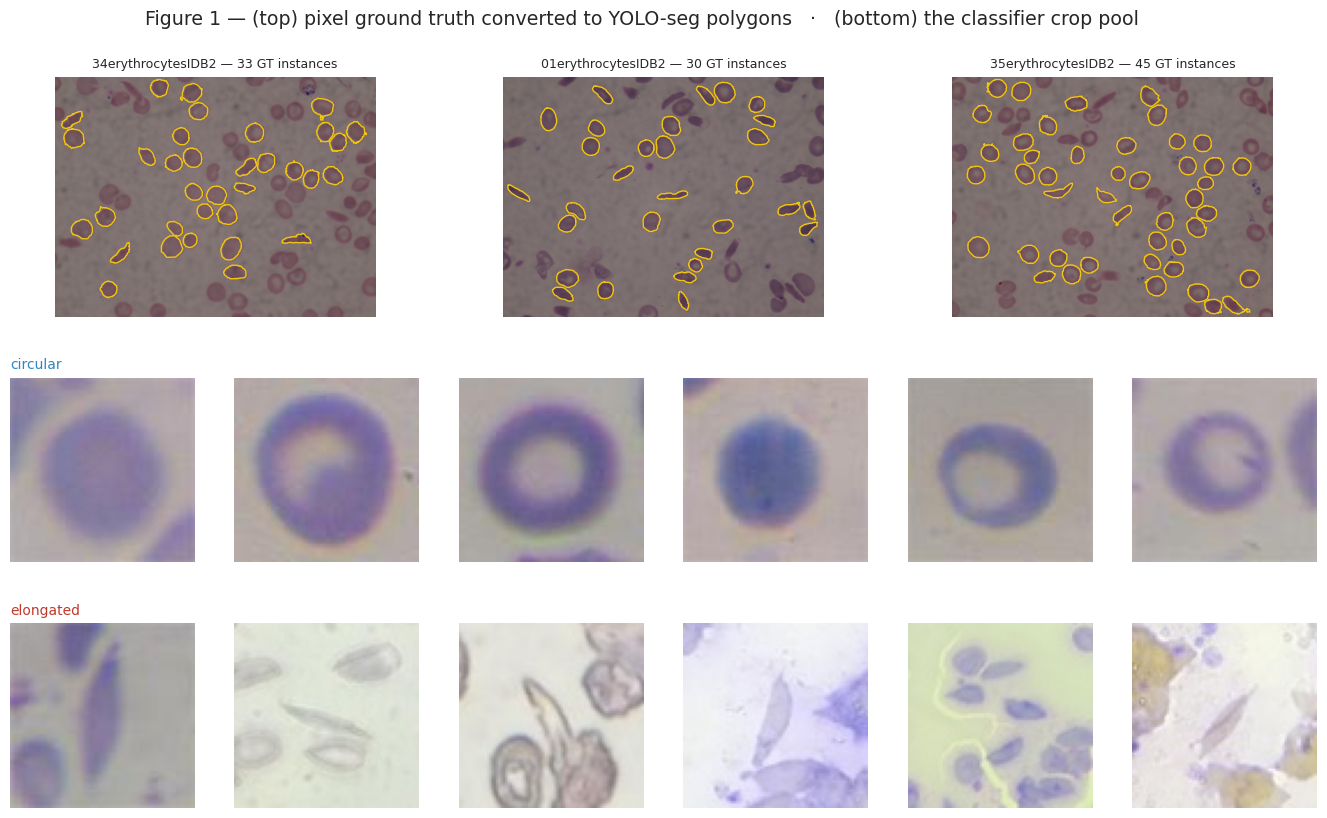

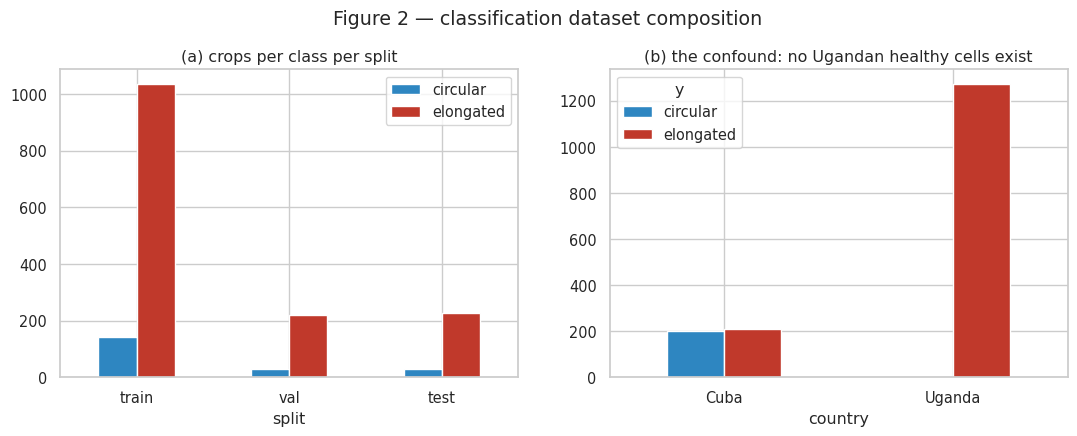


  CHECKPOINT  17_final_pipeline/data   [ok]   52.2 min
  ok    state                     0.01 MB  /ibex/user/bahajao/runs_two_stage/state.json
  ok    gt_labels                 1.21 MB  /ibex/user/bahajao/runs_two_stage/labels_gt
  ok    sam_labels               31.55 MB  /ibex/user/bahajao/runs_two_stage/labels_sam
  ok    seg_dataset             350.47 MB  /ibex/user/bahajao/runs_two_stage/seg_ds
  ok    crops_csv                 0.26 MB  /ibex/user/bahajao/runs_two_stage/tables/crop_splits.csv
  ok    unpacked_data           327.94 MB  /ibex/user/bahajao/scd_data
  metric  gt_smears              78.0
  metric  gt_instances           2118.0
  metric  sam_smears             307.0
  metric  sam_label_iou          0.506026
  metric  sam_label_recall@50    0.997003
  metric  cell_area_p1           0.001526
  metric  cell_area_p50          0.003214
  metric  cell_area_p99          0.017707
  metric  seg_train_smears       308.0
  metric  seg_val_smears         77.0
  metric  benchmark_sm

{'nb': '17_final_pipeline/data',
 'status': 'ok',
 'finished': '2026-08-04 11:12:11',
 'minutes': 52.23,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'n_gpu': 1,
 'vram_gb': 79.3,
 'cpus': 8,
 'workers': 7,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49993699',
 'runs_dir': '/ibex/user/bahajao/runs_two_stage',
 'metrics': {'gt_smears': 78.0,
  'gt_instances': 2118.0,
  'sam_smears': 307.0,
  'sam_label_iou': 0.506026,
  'sam_label_recall@50': 0.997003,
  'cell_area_p1': 0.001526,
  'cell_area_p50': 0.003214,
  'cell_area_p99': 0.017707,
  'seg_train_smears': 308.0,
  'seg_val_smears': 77.0,
  'benchmark_smears': 17.0,
  'crops': 1686.0,
  'train_crops': 1178.0,
  'test_crops': 258.0,
  'group_leaks': 0.0},
 'artefacts': {'state': {'path': '/ibex/user/bahajao/runs_two_stage/state.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.01,
   'modified': '2026-08-04 11:12'},
  'gt_labels': {'path': '/ibex/user/bahajao/runs_two_stage/labels_gt',
   'exists': 

: 

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
#  2 · DATA  —  unpack the zip · pixel-GT seed labels · cell size · SAM
#               pseudo-labels · the YOLO dataset · the classifier crop split
#
#  THE ZIP IS THE DATASET. One 344 MB archive is what you rsync to IBEX; this
#  cell unpacks it to scratch once and every later cell reads the unpacked tree.
# ═════════════════════════════════════════════════════════════════════════════
if PLATFORM == 'colab':
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print('drive already mounted --', e)

_scan_errs = []                                  # unreadable dirs: a silent walk hides the cause


def _parts_map():
    return {'gt': [], 'cuba_full': '', 'cuba_circ': '', 'cuba_elong': '',
            'uganda_clean': '', 'uganda_neg': '', 'uga_elong': ''}


def scan(base, max_depth=6):
    '''find each component BY NAME / BY MASK SIGNATURE anywhere under `base`.

    followlinks=True on purpose: $HOME is small on IBEX, so the data is usually a symlink
    out to /ibex -- the default walk steps over exactly the link that matters.'''
    parts = _parts_map()
    if not base or not os.path.isdir(base):
        return parts
    seen = set()
    for r, dirs, files in os.walk(base, onerror=_scan_errs.append, followlinks=True):
        real = os.path.realpath(r)
        if real in seen:                             # already been here by another name
            dirs[:] = []
            continue
        seen.add(real)
        dirs[:] = [d for d in dirs if d not in ('__MACOSX', 'drive', 'sample_data', '.git',
                                                'runs_two_stage')]
        if r.count(os.sep) - base.count(os.sep) >= max_depth:
            dirs[:] = []
        low = {f.lower() for f in files}
        if any(f.startswith('mask-circular') for f in low) and \
           any(f.startswith('mask-elongated') for f in low):
            parts['gt'].append(r)
            continue
        name = os.path.basename(r).lower()
        if name == 'positive_sickle_clean':
            parts['uganda_clean'] = r
        elif name == 'negative_normal':
            parts['uganda_neg'] = r
        elif name == 'cells_circular':
            parts['cuba_circ'] = r
        elif name == 'cells_elongated':
            parts['uga_elong' if 'uganda' in r.lower() else 'cuba_elong'] = r
        elif name == 'full_smears' and 'cuba' in r.lower() and imgs_in(r):
            parts['cuba_full'] = r
    return parts


def n_found(p):
    return int(bool(p['gt'])) + sum(1 for k, v in p.items() if k != 'gt' and v)


def find_zip():
    '''the archive: SCD_DATA_ZIP, else a known filename, else any zip whose INDEX holds
    the components (reads the central directory only -- it never inflates to check)'''
    if CFG['data_zip']:
        assert os.path.isfile(CFG['data_zip']), f"SCD_DATA_ZIP is not a file: {CFG['data_zip']}"
        return CFG['data_zip']
    hints = [h for i, h in enumerate(CFG['zip_hints'])
             if h and os.path.isdir(h) and h not in CFG['zip_hints'][:i]]
    for h in hints:                                              # fast path: known filenames
        for n in CFG['zip_names']:
            if os.path.isfile(os.path.join(h, n)):
                return os.path.join(h, n)
    for h in hints:                                              # slow path: read zip indexes
        for z in sorted(glob.glob(os.path.join(h, '**', '*.zip'), recursive=True))[:40]:
            try:
                with zipfile.ZipFile(z) as zf:
                    names = '\n'.join(zf.namelist()[:20000]).lower()
            except Exception:
                continue
            if 'cells_circular' in names and 'mask-circular' in names:
                return z
    return ''


def unpack(z, dest):
    '''extract once, then never again -- a complete tree at `dest` short-circuits this'''
    if n_found(scan(dest)) == 7:
        print(f'already unpacked -> {dest}   (delete it to force a fresh extract)')
        return
    os.makedirs(dest, exist_ok=True)
    with zipfile.ZipFile(z) as zf:
        members = [m for m in zf.namelist()
                   if '__MACOSX' not in m and not os.path.basename(m).startswith('._')]
        mb = sum(i.file_size for i in zf.infolist()) / 2 ** 20
        print(f'unpacking {os.path.basename(z)}  ({len(members)} members, {mb:.0f} MB)\n'
              f'  -> {dest}')
        t0 = time.time()
        zf.extractall(dest, members=members)
    print(f'  extracted in {time.time() - t0:.0f} s')


# ── 2a · resolve the data: explicit root wins, otherwise the zip ─────────────
ZIP = ''
if CFG['data_root'] and n_found(scan(CFG['data_root'])) == 7:
    parts = scan(CFG['data_root'])
    print(f"using SCD_DATA_ROOT (complete, zip not needed) -> {CFG['data_root']}")
else:
    if CFG['data_root']:
        print(f"!! SCD_DATA_ROOT is set but incomplete, falling back to the zip: "
              f"{CFG['data_root']}")
    ZIP = find_zip()
    assert ZIP, ('Sickle_Cell_Dataset zip not found.\n'
                 '  searched: ' + ', '.join(h for h in CFG['zip_hints'] if os.path.isdir(h)) +
                 "\n  FIX: export SCD_DATA_ZIP=/path/to/Sickle_Cell_Dataset_1.zip"
                 '\n  On IBEX:  rsync -a --info=progress2 \\'
                 '\n              ~/Downloads/scd_pipeline/Sickle_Cell_Dataset_1.zip \\'
                 '\n              $USER@ilogin.ibex.kaust.edu.sa:/ibex/user/$USER/')
    print(f'dataset zip -> {ZIP}   ({os.path.getsize(ZIP) / 2 ** 20:.0f} MB on disk)')
    unpack(ZIP, CFG['extract_dir'])
    parts = scan(CFG['extract_dir'])
    print(f"  {n_found(parts)}/7 components under {CFG['extract_dir']}")

gt_dirs = sorted(parts['gt'])
cuba_full, cuba_circ, cuba_elong = parts['cuba_full'], parts['cuba_circ'], parts['cuba_elong']
uganda_clean, uganda_neg, uga_elong = parts['uganda_clean'], parts['uganda_neg'], parts['uga_elong']

manifest = pd.DataFrame([
    ('Cuba  full smears',            cuba_full,          len(imgs_in(cuba_full))),
    ('Cuba  cells_circular',         cuba_circ,          len(imgs_in(cuba_circ))),
    ('Cuba  cells_elongated',        cuba_elong,         len(imgs_in(cuba_elong))),
    ('Cuba  GT mask smears',         '_supplementary/*', len(gt_dirs)),
    ('Uganda positive_sickle_clean', uganda_clean,       len(imgs_in(uganda_clean))),
    ('Uganda negative_normal',       uganda_neg,         len(imgs_in(uganda_neg))),
    ('Uganda cells_elongated',       uga_elong,          len(imgs_in(uga_elong))),
], columns=['component', 'path', 'n'])

missing = manifest[manifest.n == 0]['component'].tolist()
assert not missing, ('\nComponents missing from the unpacked tree: ' + ', '.join(missing) +
                     '\n' + manifest.to_string(index=False) +
                     f"\n  extracted to: {CFG['extract_dir']}"
                     '\n  The zip may be truncated -- check its size against the source and'
                     '\n  delete the extract dir to force a clean re-extract.')

root = os.path.commonpath([p for p in (cuba_full, cuba_circ, cuba_elong, uganda_clean,
                                       uganda_neg, uga_elong) if p] + gt_dirs)
CFG['data_root'] = root
manifest['path'] = manifest['path'].apply(
    lambda p: os.path.relpath(p, root) if p.startswith(root) else p)
manifest.to_csv(os.path.join(TAB, 'manifest.csv'), index=False)
print('\ndata_root ->', root, '\n')
print(manifest.to_string(index=False))
save_state(data_root=root, data_zip=ZIP, cuba_full=cuba_full, cuba_circ=cuba_circ,
           cuba_elong=cuba_elong, uganda_clean=uganda_clean, uganda_neg=uganda_neg,
           uga_elong=uga_elong, gt_dirs=gt_dirs, platform=PLATFORM, tier=TIER, gpu=GPU)

# ── 2b · seed segmentation labels from Cuba's pixel ground truth ──────────────
#  Connected contours in the hand-made mask-circular / mask-elongated JPEGs are REAL cell
#  instances. They are the trustworthy seed labels -- and the only data the segmenter is
#  ever graded on. Both classes collapse to one `RBC` class: stage 1 finds cells, stage 2
#  names them. set2's masks are 1/4 the resolution of their source, which is harmless
#  because YOLO polygons are normalised by the dimensions of the mask they came from.
GT_DIR = os.path.join(CFG['runs_dir'], 'labels_gt')
os.makedirs(GT_DIR, exist_ok=True)


def find_one(d, stem):
    for f in sorted(os.listdir(d)):
        if f.lower().startswith(stem) and f.lower().endswith(IMG_EXT):
            return os.path.join(d, f)
    return ''


gt_records, n_inst, n_circ, n_elong = [], 0, 0, 0
for d in gt_dirs:
    src = find_one(d, 'source')
    if not src:                                    # one set3 folder ships no source.jpg
        continue
    polys, per_class = [], {}
    for cls in ('circular', 'elongated'):
        mp = find_one(d, f'mask-{cls}')
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE) if mp else None
        if m is None:
            continue
        p = mask_to_polys((m > 127).astype(np.uint8))     # masks are white-on-black JPEGs
        polys += p
        per_class[cls] = len(p)
    if not polys:
        continue
    txt = os.path.join(GT_DIR, os.path.basename(d) + '.txt')
    with open(txt, 'w') as f:
        for p in polys:
            f.write('0 ' + ' '.join(f'{v:.6f}' for v in p) + '\n')
    gt_records.append({'smear': os.path.basename(d), 'img': src, 'label': txt, 'n': len(polys)})
    n_inst += len(polys)
    n_circ += per_class.get('circular', 0)
    n_elong += per_class.get('elongated', 0)

gt = pd.DataFrame(gt_records)
gt.to_csv(os.path.join(TAB, 'gt_seed_labels.csv'), index=False)
print(f'\nGT smears labelled : {len(gt)} / {len(gt_dirs)}')
print(f'GT cell instances  : {n_inst}   (circular {n_circ} + elongated {n_elong})')
print(f'cells per smear    : mean {gt.n.mean():.1f}   min {gt.n.min()}   max {gt.n.max()}')
assert len(gt) >= 50 and n_inst > 500, 'Too few GT instances -- check the mask filenames.'

# how big is a real cell? every blob filter below is anchored to this measurement rather
# than to guessed constants -- a first draft used guessed constants and threw most cells away.
gt_area = np.array([cv2.contourArea(np.array(line.split()[1:], np.float32).reshape(-1, 2))
                    for r in gt.itertuples() for line in open(r.label)])
A1, A50, A99 = [float(v) for v in np.percentile(gt_area, [1, 50, 99])]
print(f'cell area / frame  : p1 {A1:.5f}   median {A50:.5f}   p99 {A99:.5f}')
save_state(A1=A1, A50=A50, A99=A99, gt_csv=os.path.join(TAB, 'gt_seed_labels.csv'))

# ── 2c · enlarge the training set with SAM pseudo-labels, but AUDIT SAM first ──
#  78 labelled smears is thin for a detector. SAM auto-masks the unlabelled smears, but a
#  raw SAM mask set contains everything -- background, the field-of-view disc, plasma
#  texture -- so a cell-sized filter is required. The filter is FITTED, not guessed: its
#  search range is anchored to the A1/A99 just measured, candidates are swept against the
#  pixel-perfect GT smears, and the achieved IoU is printed as the honest quality bound on
#  every SAM-derived label. SAM is a LABELLING TOOL here and is never itself graded.
#
#  This is the single most expensive block in the notebook: on an A100 with vit_h it is
#  most of the runtime. Every label file it writes is reused on a re-run.
sam_df = pd.DataFrame(columns=['smear', 'img', 'label', 'n', 'source'])
sam_iou = sam_rec = float('nan')
SAM_DIR = os.path.join(CFG['runs_dir'], 'labels_sam')

if CFG['use_sam_pseudo']:
    if not _has('segment_anything'):
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                        'git+https://github.com/facebookresearch/segment-anything.git'],
                       check=False)
        _refresh_import_path()
    from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

    # segment_anything's MaskData.to_numpy() calls .numpy() on every stat tensor it holds, and
    # numpy has no bfloat16 -- so under the A100's bf16 autocast SAM dies at the very end of
    # generate() with `TypeError: Got unsupported ScalarType BFloat16`. Upcast the half dtypes
    # on the way out instead of dropping bf16 (vit_h is most of this notebook's runtime): the
    # affected stats are IoU / stability scores and boxes, for which fp32 is lossless.
    from segment_anything.utils import amg as _amg_utils

    if not getattr(_amg_utils.MaskData, '_half_safe', False):
        def _to_numpy_half_safe(self):
            for k, v in self._stats.items():
                if isinstance(v, torch.Tensor):
                    if v.dtype in (torch.bfloat16, torch.float16):
                        v = v.float()
                    self._stats[k] = v.detach().cpu().numpy()

        _amg_utils.MaskData.to_numpy = _to_numpy_half_safe
        _amg_utils.MaskData._half_safe = True

    SAM_URL = {'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth',
               'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
               'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'}
    SAM_CKPT = os.path.join(WTS, f'sam_{CFG["sam_variant"]}.pth')
    if not os.path.exists(SAM_CKPT):
        print(f'\ndownloading SAM {CFG["sam_variant"]} ... (pre-pull this on a login node)')
        torch.hub.download_url_to_file(SAM_URL[CFG['sam_variant']], SAM_CKPT)

    sam = sam_model_registry[CFG['sam_variant']](checkpoint=SAM_CKPT).to(DEV).eval()
    amg = SamAutomaticMaskGenerator(sam, points_per_side=CFG['sam_points_bulk'],
                                    pred_iou_thresh=0.86, stability_score_thresh=0.90,
                                    min_mask_region_area=max(30, int(A1 * CFG['sam_side'] ** 2 / 16)))

    def automask(im):
        '''bf16 autocast on Ampere+ -- SAM's ViT encoder is the cost here, and it is
        inference-only, so there is no scaler and nothing to lose numerically'''
        with torch.inference_mode(), autocast_ctx():
            return amg.generate(im)

    def keep(m, HW, area_lo, area_hi, ar_max, sol_min):
        '''cell-sized-blob test on one SAM mask dict'''
        A = HW[0] * HW[1]
        if not (area_lo * A <= m['area'] <= area_hi * A):
            return False
        x, y, w, h = m['bbox']
        if w == 0 or h == 0 or max(w / h, h / w) > ar_max:
            return False
        cs, _ = cv2.findContours(m['segmentation'].astype(np.uint8),
                                 cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cs:
            return False
        hull = cv2.contourArea(cv2.convexHull(max(cs, key=cv2.contourArea)))
        return hull > 0 and m['area'] / hull >= sol_min   # RBCs are near-convex; debris is not

    t_sam = time.time()
    qc_cache = []                                # auto-mask the QC smears ONCE, then sweep
    for row in gt.sample(min(CFG['sam_qc_smears'], len(gt)), random_state=SEED).itertuples():
        im = load_rgb(row.img, CFG['sam_side'])
        gt_m = np.zeros(im.shape[:2], np.uint8)
        for poly in read_polys(row.label, im.shape[1], im.shape[0]):
            cv2.fillPoly(gt_m, [poly], 1)
        qc_cache.append((im, gt_m, automask(im)))
    print(f'QC auto-masking done on {len(qc_cache)} GT smears '
          f'({(time.time() - t_sam) / max(len(qc_cache), 1):.1f} s/smear, '
          f'SAM {CFG["sam_variant"]})')

    def score(preset):
        ious, recs = [], []
        for im, gt_m, masks in qc_cache:
            acc = [m['segmentation'] for m in masks if keep(m, im.shape[:2], *preset)]
            n_gt, lbl = cv2.connectedComponents(gt_m)
            if not acc:
                ious.append(0.0)
                recs.append(0.0)
                continue
            u = np.any(acc, axis=0)
            ious.append((u & (gt_m > 0)).sum() / max((u | (gt_m > 0)).sum(), 1))
            hits = tot = 0
            for k in range(1, n_gt):
                g = lbl == k
                if g.sum() < 20:
                    continue
                tot += 1
                if max((a & g).sum() / max((a | g).sum(), 1) for a in acc) >= 0.5:
                    hits += 1
            recs.append(hits / max(tot, 1))
        return float(np.mean(ious)), float(np.mean(recs))

    # the widest preset reaches down to A1/8 because Uganda's wide-field phone photos show
    # many more, hence relatively smaller, cells than Cuba's fixed 100x rig.
    PRESETS = [(A1 / 2, A99 * 2, 6.0, 0.60), (A1, A99, 5.0, 0.70),
               (A1 / 8, A99 * 4, 8.0, 0.50), (A1 * 2, A99, 4.0, 0.85)]
    sweep = pd.DataFrame([dict(zip(['area_lo', 'area_hi', 'ar_max', 'solidity'], p),
                               **dict(zip(['mean_IoU', 'recall@0.5'], score(p)))) for p in PRESETS])
    best = PRESETS[int(sweep.mean_IoU.idxmax())]
    sam_iou = float(sweep.mean_IoU.max())
    sam_rec = float(sweep.loc[sweep.mean_IoU.idxmax(), 'recall@0.5'])
    print(sweep.round(5).to_string(index=False))
    print(f'\nchosen filter -> area {best[0]:.2e}..{best[1]:.2e} of frame, AR<={best[2]}, '
          f'solidity>={best[3]}')
    print(f'SAM label quality vs Cuba GT: mean union-IoU {sam_iou:.3f} | '
          f'instance recall@0.5 {sam_rec:.3f}')
    sweep.to_csv(os.path.join(TAB, 'sam_filter_sweep.csv'), index=False)
    save_state(sam_preset=list(best), sam_label_iou=sam_iou, sam_label_recall50=sam_rec,
               sam_ckpt=SAM_CKPT)

    os.makedirs(SAM_DIR, exist_ok=True)          # rerun-safe: finished images are skipped
    todo = ([(p, 'cuba_full') for p in imgs_in(cuba_full)[:CFG['sam_max']['cuba_full']]] +
            [(p, 'uganda_clean') for p in imgs_in(uganda_clean)[:CFG['sam_max']['uganda_clean']]] +
            [(p, 'uganda_neg') for p in imgs_in(uganda_neg)[:CFG['sam_max']['uganda_neg']]])
    sam_records, t0 = [], time.time()
    for i, (p, src) in enumerate(todo):
        stem = src + '__' + os.path.splitext(os.path.basename(p))[0]
        txt = os.path.join(SAM_DIR, stem + '.txt')
        if not os.path.exists(txt):
            im = load_rgb(p, CFG['sam_side'])
            polys = []
            for m in automask(im):
                if keep(m, im.shape[:2], *best):
                    polys += mask_to_polys(m['segmentation'].astype(np.uint8))
            with open(txt, 'w') as f:
                for q in polys:
                    f.write('0 ' + ' '.join(f'{v:.6f}' for v in q) + '\n')
        n = sum(1 for _ in open(txt))
        if n:
            sam_records.append({'smear': stem, 'img': p, 'label': txt, 'n': n, 'source': src})
        if (i + 1) % 25 == 0:
            done, rate = i + 1, (time.time() - t0) / (i + 1)
            print(f'  SAM pseudo-label {done}/{len(todo)}  ({rate:.1f} s/smear, '
                  f'~{rate * (len(todo) - done) / 60:.0f} min left)')
    sam_df = pd.DataFrame(sam_records)
    print(f'\nSAM-labelled smears: {len(sam_df)} | instances: {int(sam_df.n.sum())} '
          f'| {(time.time() - t_sam) / 60:.1f} min total')
    free_gpu('sam', 'amg')
else:
    print('\nSAM pseudo-labels disabled -- training on the pixel-GT smears only.')

# ── 2d · assemble the YOLO-format segmentation dataset, split BY SMEAR ────────
#  Ground truth first, SAM pseudo-labels on top. Every ground-truth smear that lands in
#  `val` is reserved as benchmark data, and the segmenter is never SCORED on a SAM label.
YDS = os.path.join(CFG['runs_dir'], 'seg_ds')
for s in ('train', 'val'):
    os.makedirs(os.path.join(YDS, 'images', s), exist_ok=True)
    os.makedirs(os.path.join(YDS, 'labels', s), exist_ok=True)

allrec = gt.assign(source='cuba_gt')[['smear', 'img', 'label', 'n', 'source']].to_dict('records')
allrec += sam_df.to_dict('records')

rng = np.random.default_rng(SEED)
order = rng.permutation(len(allrec))
n_val = int(len(allrec) * CFG['seg_val_frac'])
for j, idx in enumerate(order):
    r = allrec[idx]
    r['split'] = 'val' if j < n_val else 'train'
    dst = os.path.join(YDS, 'images', r['split'], r['smear'] + os.path.splitext(r['img'])[1])
    if not os.path.exists(dst):
        shutil.copy(r['img'], dst)
    shutil.copy(r['label'], os.path.join(YDS, 'labels', r['split'], r['smear'] + '.txt'))

seg_df = pd.DataFrame(allrec)
seg_df.to_csv(os.path.join(TAB, 'seg_dataset.csv'), index=False)
with open(os.path.join(YDS, 'data.yaml'), 'w') as f:
    f.write(f"path: {YDS}\ntrain: images/train\nval: images/val\nnc: 1\nnames: ['RBC']\n")

bench_stems = seg_df[(seg_df.source == 'cuba_gt') & (seg_df.split == 'val')].smear.tolist()
assert bench_stems, 'no GT smear in val -- lower seg_val_frac or re-seed'
save_state(YDS=YDS, seg_csv=os.path.join(TAB, 'seg_dataset.csv'), bench_stems=bench_stems)
print(f"\nseg dataset: {(seg_df.split == 'train').sum()} train / {(seg_df.split == 'val').sum()} "
      f"val smears | {int(seg_df.n.sum())} instances "
      f"| GT-derived {int(seg_df[seg_df.source == 'cuba_gt'].n.sum())}, "
      f"SAM-derived {int(seg_df[seg_df.source != 'cuba_gt'].n.sum())}")
print(f'benchmark smears (held-out, pixel GT, never SAM): {len(bench_stems)}')

# ── 2e · the classifier crop pool, split BY SOURCE SMEAR ──────────────────────
#  circular = Cuba/cells_circular.  elongated = Cuba/cells_elongated + Uganda/cells_elongated.
#
#  THE GEOGRAPHIC CONFOUND, STATED PLAINLY: Uganda contributes no healthy cells, so the
#  `circular` class is 100% Cuban. Country and label are partially entangled -- a network can
#  score well by learning "Cuban stain and optics => circular" without learning cell shape.
#  The per-population recall printed in cell 4 is there to keep that visible.
rows = ([{'path': p, 'y': 0, 'country': 'Cuba', 'grp': ''} for p in imgs_in(cuba_circ)] +
        [{'path': p, 'y': 1, 'country': 'Cuba', 'grp': ''} for p in imgs_in(cuba_elong)])
for p in imgs_in(uga_elong):
    m = re.search(r'(uganda_pos_\d+)', os.path.basename(p))        # exact source photo
    rows.append({'path': p, 'y': 1, 'country': 'Uganda',
                 'grp': m.group(1) if m else 'uganda_' + os.path.basename(p)})

crops = pd.DataFrame(rows).sort_values('path').reset_index(drop=True)
# store the path RELATIVE to data_root as well: the extract dir can move between jobs
# (a different scratch, or $TMPDIR), and cell 4 re-joins rather than breaking.
crops['rel'] = [os.path.relpath(p, root) for p in crops.path]
for y in (0, 1):        # Cuba's released crops carry no smear ID -> contiguous ID blocks stand
    idx = crops.index[(crops.country == 'Cuba') & (crops.y == y)]   # in. Safer than a per-cell
    for k, i in enumerate(sorted(idx)):                             # split, but an approximation
        crops.loc[i, 'grp'] = f'cuba_{y}_blk{k // CFG["cuba_block"]:03d}'

g = crops.groupby('grp').agg(y=('y', 'first')).reset_index()        # split GROUPS 70/15/15,
tr_g, va_g, te_g = [], [], []                                       # stratified by group label
for y in (0, 1):
    ids = g[g.y == y].grp.sample(frac=1, random_state=SEED).tolist()
    n_te = int(round(len(ids) * CFG['test_frac']))
    n_va = int(round(len(ids) * CFG['val_frac']))
    te_g += ids[:n_te]
    va_g += ids[n_te:n_te + n_va]
    tr_g += ids[n_te + n_va:]

crops['split'] = np.select([crops.grp.isin(tr_g), crops.grp.isin(va_g)], ['train', 'val'], 'test')
leak = (set(tr_g) & set(va_g)) | (set(tr_g) & set(te_g)) | (set(va_g) & set(te_g))
assert not leak, f'GROUP LEAK: {list(leak)[:5]}'
CROPS_CSV = os.path.join(TAB, 'crop_splits.csv')
crops.to_csv(CROPS_CSV, index=False)
save_state(crops_csv=CROPS_CSV)

tab = crops.pivot_table(index='split', columns='y', values='path', aggfunc='count') \
    .reindex(index=['train', 'val', 'test'], columns=[0, 1]).fillna(0).astype(int)
tab.columns = CFG['classes']
by_country = crops.pivot_table(index='country', columns='y', values='path', aggfunc='count') \
    .fillna(0).astype(int).rename(columns=dict(enumerate(CFG['classes'])))
print('\n' + tab.to_string())
print('groups:', len(tr_g), 'train /', len(va_g), 'val /', len(te_g), 'test  (none shared)')
print(by_country.to_string())

# ── 2f · one figure: what the data actually is ────────────────────────────────
fig = plt.figure(figsize=(17, 9.5))
gsp = fig.add_gridspec(3, 6, height_ratios=[1.3, 1.0, 1.0], hspace=0.30, wspace=0.15)
for c, row in enumerate(gt.sample(3, random_state=SEED).itertuples()):
    ax = fig.add_subplot(gsp[0, c * 2:c * 2 + 2])
    im = load_rgb(row.img, 900)
    ax.imshow(im)
    for poly in read_polys(row.label, im.shape[1], im.shape[0]):
        ax.plot(*np.vstack([poly, poly[:1]]).T, lw=1.0, color='#F1C40F')
    ax.set_title(f'{row.smear} — {row.n} GT instances', fontsize=9)
    ax.axis('off')
for r, y in enumerate((0, 1)):
    for c, p in enumerate(crops[crops.y == y].sample(6, random_state=SEED).path):
        ax = fig.add_subplot(gsp[r + 1, c])
        ax.imshow(load_rgb(p))
        ax.axis('off')
        if c == 0:
            ax.set_title(CFG['classes'][y], loc='left', color=CLR[CFG['classes'][y]], fontsize=10)
fig.suptitle('Figure 1 — (top) pixel ground truth converted to YOLO-seg polygons   ·   '
             '(bottom) the classifier crop pool', y=0.95)
savefig(fig, 'final_01_data.png')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
tab.plot(kind='bar', ax=ax[0], color=[CLR['circular'], CLR['elongated']])
ax[0].set_title('(a) crops per class per split')
ax[0].tick_params(axis='x', rotation=0)
by_country.plot(kind='bar', ax=ax[1], color=[CLR['circular'], CLR['elongated']])
ax[1].set_title('(b) the confound: no Ugandan healthy cells exist')
ax[1].tick_params(axis='x', rotation=0)
fig.suptitle('Figure 2 — classification dataset composition', y=1.03)
savefig(fig, 'final_02_class_balance.png')
plt.show()

checkpoint('data',
           produced={'state': STATE_PATH, 'gt_labels': GT_DIR,
                     'sam_labels': SAM_DIR if CFG['use_sam_pseudo'] else '',
                     'seg_dataset': YDS, 'crops_csv': CROPS_CSV,
                     'unpacked_data': CFG['extract_dir'] if ZIP else ''},
           metrics={'gt_smears': len(gt), 'gt_instances': n_inst,
                    'sam_smears': len(sam_df), 'sam_label_iou': sam_iou,
                    'sam_label_recall@50': sam_rec,
                    'cell_area_p1': A1, 'cell_area_p50': A50, 'cell_area_p99': A99,
                    'seg_train_smears': int((seg_df.split == 'train').sum()),
                    'seg_val_smears': int((seg_df.split == 'val').sum()),
                    'benchmark_smears': len(bench_stems), 'crops': len(crops),
                    'train_crops': int((crops.split == 'train').sum()),
                    'test_crops': int((crops.split == 'test').sum()),
                    'group_leaks': len(leak)},
           notes=f'from {os.path.basename(ZIP) if ZIP else "SCD_DATA_ROOT"}; '
                 'both splits are by source smear')

## 3 · Segmentation — fine-tuned YOLO-seg

Stage 1 only has to answer *where are the cells*, so both ground-truth classes collapse into one
`RBC` class. Trained at 1024 px because cells are small relative to a whole smear, with
`batch=-1` so Ultralytics auto-sizes the batch to whatever card it lands on.

Two different numbers come out of here and they are **not** the same thing:

* **Ultralytics `val()`** — mask mAP over the whole val split, SAM-pseudo-labelled smears
  included. It is the number a YOLO paper quotes, and it partly measures *"how well did you
  imitate SAM"*.
* **`seg_benchmark()`** — instance-level F1 at IoU 0.5 on held-out smears with **pixel ground
  truth only**. That is the honest one, and it is what the end-to-end ceiling is built from.

On A100 this is the **medium** model (`yolo11m-seg.pt`), not small — cells are dense and small
relative to the field, which is exactly where the extra capacity pays. `batch=-1` lets AutoBatch
fill ~60 % of the card; if the allocation has more than one GPU, training switches to DDP across
all of them with an explicit batch, because AutoBatch and DDP are mutually exclusive.

To use YOLO26 instead, set `CFG['yolo_weights'] = 'yolo26m-seg.pt'` in cell 1 — it needs
`ultralytics >= 8.4`, and `load_yolo()` falls back to `yolo11s-seg.pt` on an older pin rather
than dying mid-run.


In [3]:
# ═════════════════════════════════════════════════════════════════════════════
#  3 · SEGMENTATION  —  fine-tune YOLO-seg (one class: RBC) and grade it on the
#                       held-out smears that carry PIXEL ground truth
# ═════════════════════════════════════════════════════════════════════════════
from ultralytics import YOLO

try:                                      # compute nodes are offline: no telemetry, no sync
    from ultralytics import settings as _ul
    _ul.update({'sync': False, 'runs_dir': os.path.join(CFG['runs_dir'], 'yolo'),
                'weights_dir': WTS, 'datasets_dir': CFG['runs_dir']})
except Exception as e:
    print('(ultralytics settings not updated --', type(e).__name__, e, ')')

EVAL_SIDE = CFG['eval_side']


class Inst:
    '''one instance mask as (bbox, cropped bool array).

    200 cells x 3 MP as full-frame arrays is ~600 MB; this is ~2 MB.'''
    __slots__ = ('x0', 'y0', 'x1', 'y1', 'm', 'score', 'area')

    def __init__(self, mask, score=1.0):
        ys, xs = np.nonzero(mask)
        self.x0, self.x1 = int(xs.min()), int(xs.max()) + 1
        self.y0, self.y1 = int(ys.min()), int(ys.max()) + 1
        self.m = np.ascontiguousarray(mask[self.y0:self.y1, self.x0:self.x1])
        self.score = float(score)
        self.area = int(self.m.sum())


def to_insts(masks, scores=None):
    out = []
    for i, m in enumerate(masks):
        m = np.asarray(m, bool)
        if m.sum() < 12:                       # a 3x4 blob is not a cell
            continue
        out.append(Inst(m, 1.0 if scores is None else scores[i]))
    return out


def iou(a, b):
    x0, y0 = max(a.x0, b.x0), max(a.y0, b.y0)
    x1, y1 = min(a.x1, b.x1), min(a.y1, b.y1)
    if x1 <= x0 or y1 <= y0:                   # bbox pre-filter: most pairs die here
        return 0.0
    ia = a.m[y0 - a.y0:y1 - a.y0, x0 - a.x0:x1 - a.x0]
    ib = b.m[y0 - b.y0:y1 - b.y0, x0 - b.x0:x1 - b.x0]
    inter = int(np.count_nonzero(ia & ib))
    return 0.0 if inter == 0 else inter / (a.area + b.area - inter)


def match(M, scores, thr):
    '''greedy score-ordered matching on a cached IoU matrix -> (tp flags, matched IoUs)'''
    order = np.argsort(-np.asarray(scores, float)) if len(scores) else np.array([], int)
    taken = np.zeros(M.shape[1], bool)
    tp = np.zeros(M.shape[0], bool)
    ious = []
    for i in order:
        row = np.where(taken, -1.0, M[i])
        if row.size == 0:
            continue
        j = int(row.argmax())
        if row[j] >= thr:
            taken[j] = True
            tp[i] = True
            ious.append(float(row[j]))
    return tp, ious


def ap_at(per_image, thr):
    '''single-class COCO 101-point AP at one IoU threshold, pooled over images'''
    n_gt = sum(n for n, _, _ in per_image)
    recs = []
    for n, scores, M in per_image:
        tp, _ = match(M, scores, thr)
        recs += list(zip(scores, tp.tolist()))
    if n_gt == 0:
        return float('nan')
    if not recs:
        return 0.0                                        # detected nothing, but cells were there
    recs.sort(key=lambda r: -r[0])
    t = np.cumsum([r[1] for r in recs], dtype=float)
    f = np.cumsum([not r[1] for r in recs], dtype=float)
    rec = t / n_gt
    prec = np.maximum.accumulate((t / np.maximum(t + f, 1e-9))[::-1])[::-1]   # monotone envelope
    return float(np.mean(np.interp(np.linspace(0, 1, 101), rec, prec, left=prec[0], right=0.0)))


def load_gt_insts(stem, YDS, split='val'):
    '''pixel ground truth for one smear, at EVAL_SIDE, one Inst per labelled cell'''
    img = next(iter(glob.glob(os.path.join(YDS, 'images', split, stem + '.*'))), '')
    lab = os.path.join(YDS, 'labels', split, stem + '.txt')
    if not img or not os.path.exists(lab):
        return None, []
    rgb = load_rgb(img, EVAL_SIDE)
    H, W = rgb.shape[:2]
    insts = []
    for poly in read_polys(lab, W, H):
        m = np.zeros((H, W), np.uint8)
        cv2.fillPoly(m, [poly], 1)
        if m.sum() >= 12:
            insts.append(Inst(m > 0))
    return rgb, insts


def seg_benchmark(predict_fn, method, notes='', extra=None, show=4):
    '''predict_fn(rgb_uint8) -> (list_of_bool_masks, list_of_scores) at the SAME size as rgb.

    Scored on held-out smears with PIXEL ground truth only -- SAM-pseudo-labelled smears are
    excluded, because grading against SAM's own labels would be circular. The headline is
    INSTANCE-level F1@IoU0.5: a cell counts as found only if one predicted mask overlaps it by
    >=50%. Pixel IoU is reported too, but a method can score well on it while merging every
    touching cell into one blob. Seconds per smear is recorded because a segmenter that needs
    40 s per slide is not a screening tool no matter what its F1 is.'''
    YDS, stems = need('YDS', 'bench_stems')
    per_image, rows, gallery = [], [], []
    for k, stem in enumerate(stems):
        rgb, gts = load_gt_insts(stem, YDS)
        if rgb is None or not gts:
            continue
        t0 = time.time()
        masks, scores = predict_fn(rgb)
        dt = time.time() - t0
        preds = to_insts(masks, scores)
        M = np.zeros((len(preds), len(gts)), np.float32)      # computed ONCE, reused per threshold
        for i, p in enumerate(preds):
            for j, g in enumerate(gts):
                M[i, j] = iou(p, g)
        sc = [p.score for p in preds]
        per_image.append((len(gts), sc, M))
        tp, mi = match(M, sc, 0.5)
        gu = np.zeros(rgb.shape[:2], bool)
        for g in gts:
            gu[g.y0:g.y1, g.x0:g.x1] |= g.m
        pu = np.zeros(rgb.shape[:2], bool)
        for p in preds:
            pu[p.y0:p.y1, p.x0:p.x1] |= p.m
        rows.append({'smear': stem, 'gt_cells': len(gts), 'pred_cells': len(preds),
                     'tp@50': int(tp.sum()), 'mean_matched_iou': float(np.mean(mi)) if mi else 0.0,
                     'pixel_iou': float((gu & pu).sum() / max((gu | pu).sum(), 1)), 'sec': dt})
        if len(gallery) < show:
            gallery.append((rgb, gts, preds, stem))
        if (k + 1) % 10 == 0:
            print(f'  {method}: {k + 1}/{len(stems)} smears')

    per = pd.DataFrame(rows)
    tp = int(per['tp@50'].sum())
    n_gt, n_pr = int(per.gt_cells.sum()), int(per.pred_cells.sum())
    rec, prec = tp / max(n_gt, 1), tp / max(n_pr, 1)
    res = {'method': method,
           'f1@50': 2 * prec * rec / max(prec + rec, 1e-9),
           'precision@50': prec, 'recall@50': rec,
           'mean_matched_iou': float(per.mean_matched_iou.mean()),
           'pixel_iou': float(per.pixel_iou.mean()),
           'mask_ap50': ap_at(per_image, 0.5),
           'mask_ap50_95': float(np.nanmean([ap_at(per_image, t) for t in np.arange(0.5, 1.0, .05)])),
           'gt_cells': n_gt, 'pred_cells': n_pr, 'n_smears': len(per),
           'sec_per_smear': float(per.sec.mean()),
           'tier': TIER, 'gpu': GPU, 'eval_side': EVAL_SIDE, 'notes': notes,
           'timestamp': time.strftime('%Y-%m-%d %H:%M')}
    res.update(extra or {})
    per.to_csv(os.path.join(BENCH, f'{method}_per_smear.csv'), index=False)
    json.dump(res, open(os.path.join(BENCH, f'{method}.json'), 'w'), indent=2, default=float)

    print('\n' + '=' * 72)
    print(f'  {method}   ({len(per)} held-out GT smears, {n_gt} real cells)')
    print('=' * 72)
    for k in ('f1@50', 'precision@50', 'recall@50', 'mean_matched_iou', 'pixel_iou',
              'mask_ap50', 'mask_ap50_95', 'sec_per_smear'):
        print(f'  {k:20s} {res[k]:.4f}')

    if gallery:
        fig, axes = plt.subplots(2, len(gallery), figsize=(4.2 * len(gallery), 8.6), squeeze=False)
        for c, (rgb, gts, preds, stem) in enumerate(gallery):
            for r, (insts, ttl, col) in enumerate([(gts, 'ground truth', (241, 196, 15)),
                                                   (preds, method, (46, 204, 113))]):
                ov = rgb.astype(float).copy()
                for it in insts:
                    sub_ = ov[it.y0:it.y1, it.x0:it.x1]
                    sub_[it.m] = 0.5 * sub_[it.m] + 0.5 * np.array(col, float)
                axes[r, c].imshow(ov.astype(np.uint8))
                axes[r, c].set_title(f'{stem[:20]} — {ttl}: {len(insts)} cells', fontsize=8)
                axes[r, c].axis('off')
        fig.suptitle(f'Figure 4 — {method}: ground truth (top) vs prediction (bottom), '
                     'held-out smears', y=1.0)
        savefig(fig, 'final_04_seg_overlays.png')
        plt.show()
    return res, per


# ── fine-tune, rerun-safe: existing weights are loaded instead of retrained ───
YDS = need('YDS')
DATA = os.path.join(YDS, 'data.yaml')
BEST = os.path.join(WTS, 'yolo_seg_rbc.pt')
AUG = dict(hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degrees=15, fliplr=0.5, flipud=0.5, scale=0.3)


def load_yolo(w):
    '''yolo26*-seg needs ultralytics >= 8.4; fall back rather than die on a pinned image'''
    try:
        return YOLO(w)
    except Exception as e:
        if w == 'yolo11s-seg.pt':
            raise
        print(f'!! {w} unavailable ({type(e).__name__}: {e})\n   falling back to yolo11s-seg.pt')
        CFG['yolo_weights'] = 'yolo11s-seg.pt'
        return YOLO(CFG['yolo_weights'])


# One A100 -> batch=-1, and AutoBatch fills ~60% of the card. More than one GPU -> DDP,
# where AutoBatch is not supported, so the batch is set explicitly and split across ranks.
DEVICE = 0 if NGPU <= 1 else list(range(NGPU))
BATCH = (-1 if NGPU <= 1 else 8 * NGPU) if DEV == 'cuda' else 2


def train_yolo(imgsz, batch):
    m = load_yolo(CFG['yolo_weights'])
    m.train(data=DATA, epochs=CFG['yolo_epochs'], imgsz=imgsz, batch=batch, seed=SEED,
            patience=CFG['yolo_patience'], deterministic=True, amp=True, device=DEVICE,
            workers=CFG['workers'], cache=CFG['yolo_cache'],
            project=os.path.join(CFG['runs_dir'], 'yolo'), name='rbc', exist_ok=False, **AUG)
    return m, str(m.trainer.save_dir)


runs = sorted(glob.glob(os.path.join(CFG['runs_dir'], 'yolo', 'rbc*')))
if os.path.exists(BEST):
    print('found trained weights ->', BEST)
    yolo, run_dir = YOLO(BEST), (runs[-1] if runs else '')
else:
    print(f'training {CFG["yolo_weights"]} @ {CFG["yolo_imgsz"]}px on {NGPU or "no"} GPU(s), '
          f'batch {"auto" if BATCH == -1 else BATCH}, cache={CFG["yolo_cache"]!r}, '
          f'{CFG["workers"]} workers')
    t0 = time.time()
    try:
        yolo, run_dir = train_yolo(CFG['yolo_imgsz'], BATCH)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print(f'!! CUDA OOM at {CFG["yolo_imgsz"]} px -- retrying at 640 px')
        CFG['yolo_imgsz'] = 640
        yolo, run_dir = train_yolo(640, BATCH)
    print(f'trained in {(time.time() - t0) / 60:.1f} min on {NGPU}x {GPU}')
    shutil.copy(os.path.join(run_dir, 'weights', 'best.pt'), BEST)
    yolo = YOLO(BEST)

# Ultralytics' own val(): mask mAP over the WHOLE val split, SAM-pseudo-labelled smears
# included. It is the number a YOLO paper quotes, and it is partly "how well did you imitate
# SAM". The seg_benchmark below -- GT-mask smears only -- is the honest one.
m = yolo.val(data=DATA, imgsz=CFG['yolo_imgsz'], split='val', verbose=False)
ultra = {'mask_mAP50': float(m.seg.map50), 'mask_mAP50_95': float(m.seg.map),
         'mask_precision': float(m.seg.mp), 'mask_recall': float(m.seg.mr),
         'box_mAP50': float(m.box.map50), 'box_mAP50_95': float(m.box.map)}
pd.Series(ultra).to_frame('value').to_csv(os.path.join(TAB, 'yolo_ultralytics_val.csv'))
print('\nUltralytics val() -- whole val split, GT + SAM labels:')
print(pd.Series(ultra).round(4).to_string())

# ── training curves, straight from the Ultralytics run directory ─────────────
csv_p = os.path.join(run_dir, 'results.csv') if run_dir else ''
if os.path.exists(csv_p):
    h = pd.read_csv(csv_p)
    h.columns = h.columns.str.strip()
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    for c in [c for c in h if c.startswith('train/') and 'loss' in c]:
        ax[0].plot(h[c], label=c.split('/')[-1])
    for c in [c for c in h if c.startswith('val/') and 'loss' in c]:
        ax[1].plot(h[c], label=c.split('/')[-1])
    for c, lab in [('metrics/mAP50(M)', 'mask mAP@50'), ('metrics/mAP50-95(M)', 'mask mAP@50-95')]:
        if c in h:
            ax[2].plot(h[c], label=lab)
    for a, t in zip(ax, ['(a) training loss', '(b) validation loss', '(c) held-out mask mAP']):
        a.set_title(t)
        a.set_xlabel('epoch')
        a.legend(fontsize=8)
    fig.suptitle(f'Figure 3 — {CFG["yolo_weights"]} fine-tuning', y=1.03)
    savefig(fig, 'final_03_seg_curves.png')
    plt.show()


# ── the honest score: pixel-GT held-out smears, automatic mode, no GT prompts ─
def yolo_predict(rgb):
    r = yolo.predict(rgb[:, :, ::-1], imgsz=CFG['yolo_imgsz'], conf=CFG['yolo_conf'], iou=0.6,
                     retina_masks=True, device=0 if DEV == 'cuda' else 'cpu', verbose=False)[0]
    if r.masks is None:
        return [], []
    H, W = rgb.shape[:2]
    mk = r.masks.data.float().cpu().numpy()
    if mk.shape[1:] != (H, W):
        mk = np.stack([cv2.resize(x, (W, H), interpolation=cv2.INTER_NEAREST) for x in mk])
    return list(mk > 0.5), r.boxes.conf.cpu().numpy().tolist()


SEG_METHOD = os.path.splitext(CFG['yolo_weights'])[0]
res_seg, per_seg = seg_benchmark(
    yolo_predict, SEG_METHOD,
    notes=f"{CFG['yolo_weights']} @ {CFG['yolo_imgsz']}px, {CFG['yolo_epochs']} ep, "
          f"conf {CFG['yolo_conf']}",
    extra={'ultralytics_val': ultra, 'weights': BEST, 'imgsz': CFG['yolo_imgsz'],
           'model': CFG['yolo_weights']})
save_state(yolo_weights_path=BEST, seg_method=SEG_METHOD, yolo_imgsz=CFG['yolo_imgsz'])

checkpoint('segmentation',
           produced={'weights': BEST, 'result': os.path.join(BENCH, f'{SEG_METHOD}.json'),
                     'per_smear': os.path.join(BENCH, f'{SEG_METHOD}_per_smear.csv'),
                     'ultralytics_run': run_dir},
           metrics={'f1@50': res_seg['f1@50'], 'precision@50': res_seg['precision@50'],
                    'recall@50': res_seg['recall@50'], 'mask_ap50': res_seg['mask_ap50'],
                    'mask_ap50_95': res_seg['mask_ap50_95'],
                    'mean_matched_iou': res_seg['mean_matched_iou'],
                    'sec_per_smear': res_seg['sec_per_smear'],
                    'ultralytics_mask_mAP50': ultra['mask_mAP50']},
           notes=f"{CFG['yolo_weights']} @ {CFG['yolo_imgsz']}px, {CFG['yolo_epochs']} epochs")

training yolo11m-seg.pt @ 1024px on 1 GPU(s), batch auto, cache='ram', 7 workers
New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.114 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (NVIDIA A100-SXM4-80GB, 81154MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/ibex/user/bahajao/runs_two_stage/seg_ds/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, 

<Figure size 1600x400 with 3 Axes>

  yolo11m-seg: 10/17 smears

  yolo11m-seg   (17 held-out GT smears, 351 real cells)
  f1@50                0.6641
  precision@50         0.5000
  recall@50            0.9886
  mean_matched_iou     0.8948
  pixel_iou            0.5455
  mask_ap50            0.8544
  mask_ap50_95         0.7139
  sec_per_smear        0.1052


<Figure size 1680x860 with 8 Axes>


  CHECKPOINT  17_final_pipeline/segmentation   [ok]   36.8 min
  ok    weights                  43.15 MB  /ibex/user/bahajao/runs_two_stage/weights/yolo_seg_rbc.pt
  ok    result                    0.00 MB  /ibex/user/bahajao/runs_two_stage/seg_bench/yolo11m-seg.json
  ok    per_smear                 0.00 MB  /ibex/user/bahajao/runs_two_stage/seg_bench/yolo11m-seg_per_smear.csv
  ok    ultralytics_run          97.05 MB  /ibex/user/bahajao/runs_two_stage/yolo/rbc-2
  metric  f1@50                  0.664115
  metric  precision@50           0.5
  metric  recall@50              0.988604
  metric  mask_ap50              0.854359
  metric  mask_ap50_95           0.713856
  metric  mean_matched_iou       0.894781
  metric  sec_per_smear          0.105169
  metric  ultralytics_mask_mAP50 0.75451


{'nb': '17_final_pipeline/segmentation',
 'status': 'ok',
 'finished': '2026-08-04 12:15:04',
 'minutes': 36.76,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'n_gpu': 1,
 'vram_gb': 79.3,
 'cpus': 8,
 'workers': 7,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49993699',
 'runs_dir': '/ibex/user/bahajao/runs_two_stage',
 'metrics': {'f1@50': 0.664115,
  'precision@50': 0.5,
  'recall@50': 0.988604,
  'mask_ap50': 0.854359,
  'mask_ap50_95': 0.713856,
  'mean_matched_iou': 0.894781,
  'sec_per_smear': 0.105169,
  'ultralytics_mask_mAP50': 0.75451},
 'artefacts': {'weights': {'path': '/ibex/user/bahajao/runs_two_stage/weights/yolo_seg_rbc.pt',
   'exists': True,
   'kind': 'file',
   'mb': 43.15,
   'modified': '2026-08-04 12:14'},
  'result': {'path': '/ibex/user/bahajao/runs_two_stage/seg_bench/yolo11m-seg.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.001,
   'modified': '2026-08-04 12:15'},
  'per_smear': {'path': '/ibex/user/bahajao/runs_two_stag

## 4 · Classification — fine-tuned InceptionV3

299 px native input, ~24 M parameters, and the only common backbone with an **auxiliary head** —
the training loop adds its `0.4 x aux_loss` term while in train mode and drops it at eval.

Two phases: first the replaced heads on frozen ImageNet features (`lr 1e-3`), then `Mixed_6*` /
`Mixed_7*` — the shape-sensitive high-level blocks — unfrozen at a 10x lower LR. Class-weighted
loss throughout, and the checkpoint kept is the epoch with the best **val macro-F1**.

**Batch stays at 64 on the A100 and `torch.compile` is deliberately not used.** Only ~1 200
training crops exist, so a bigger batch buys a handful of gradient steps per epoch and costs
optimisation quality, and compile would spend more time warming up than the whole 20-epoch run
takes. The real bottleneck here is JPEG decode, which is why workers track the SLURM allocation.


In [4]:
# ═════════════════════════════════════════════════════════════════════════════
#  4 · CLASSIFICATION  —  two-phase fine-tune of InceptionV3 on the cell crops,
#                         scored on the held-out, smear-grouped test split
# ═════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, f1_score,
                             precision_recall_fscore_support, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

NAME, SIZE = CFG['cls_name'], CFG['cls_size']
NORM = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
TF_EVAL = transforms.Compose([transforms.ToTensor(),
                              transforms.Resize((SIZE, SIZE), antialias=True), NORM])
TF_TRAIN = transforms.Compose([transforms.ToTensor(),
                               transforms.Resize((SIZE, SIZE), antialias=True),
                               transforms.RandomHorizontalFlip(),
                               transforms.RandomVerticalFlip(),
                               transforms.RandomRotation(20),
                               transforms.RandomResizedCrop(SIZE, scale=(0.8, 1.0), antialias=True),
                               NORM])

# which params are the "head", and which blocks phase 2 unfreezes. Mixed_6*/Mixed_7* are the
# shape-sensitive high-level blocks; InceptionV3 is the only common backbone with TWO heads.
HEAD = ('fc', 'AuxLogits.fc')
UNFREEZE = ('Mixed_6', 'Mixed_7', 'fc', 'AuxLogits')


def build_backbone(headless=False):
    m = tvm.inception_v3(weights=tvm.Inception_V3_Weights.IMAGENET1K_V1)
    m.fc = nn.Identity() if headless else nn.Linear(m.fc.in_features, 2)
    if not headless:
        m.AuxLogits.fc = nn.Linear(m.AuxLogits.fc.in_features, 2)
    return m.to(DEV, memory_format=torch.channels_last)


class CropDS(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        return self.tf(load_rgb(r.path)), int(r.y)


def loader(df, tf, shuffle=False, bs=None):
    '''pinned + persistent workers on A100, plain on T4/CPU'''
    kw = dict(batch_size=bs or CFG['cls_batch'], shuffle=shuffle, num_workers=CFG['workers'],
              pin_memory=(DEV == 'cuda'), drop_last=False)
    if CFG['workers'] > 0:
        kw.update(persistent_workers=True, prefetch_factor=CFG['prefetch'])
    return DataLoader(CropDS(df, tf), **kw)


@torch.no_grad()
def predict(model, dl):
    model.eval()                                  # eval mode -> aux head is off
    P, Y = [], []
    for xb, yb in dl:
        xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
        with autocast_ctx():
            out = model(xb)
        P.append(torch.softmax(out.float(), 1).cpu())
        Y.append(yb)
    return torch.cat(P).numpy(), torch.cat(Y).numpy()


def full_eval(y, prob, name, colour='#2E86C1', quiet=False):
    '''the ONE metric suite. Headline is macro-F1, not accuracy -- accuracy is dominated by
    the majority `elongated` class and would flatter every model.'''
    p1 = prob[:, 1]
    pred = prob.argmax(1)
    pr, rc, f1, sup = precision_recall_fscore_support(y, pred, labels=[0, 1], zero_division=0)
    rep = pd.DataFrame({'precision': pr, 'recall': rc, 'f1': f1, 'support': sup},
                       index=CFG['classes'])
    macro = f1_score(y, pred, average='macro')
    accu = float((pred == y).mean())
    both = len(np.unique(y)) == 2
    A = AP = float('nan')
    if both:
        fpr, tpr, _ = roc_curve(y, p1)
        A, AP = auc(fpr, tpr), average_precision_score(y, p1)

    if not quiet:
        fig, ax = plt.subplots(1, 5, figsize=(25, 4.4))
        cm = confusion_matrix(y, pred, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=CFG['classes']).plot(ax=ax[0], cmap='Blues',
                                                                      colorbar=False)
        ax[0].set_title(f'(a) confusion — counts\nacc={accu:.3f}')
        ConfusionMatrixDisplay(cm / np.maximum(cm.sum(1, keepdims=True), 1),
                               display_labels=CFG['classes']).plot(ax=ax[1], cmap='Blues',
                                                                   colorbar=False,
                                                                   values_format='.2f')
        ax[1].set_title('(b) confusion — row-normalised')
        if both:
            ax[2].plot(fpr, tpr, color=colour, label=f'AUC={A:.3f}')
            ax[2].plot([0, 1], [0, 1], '--', c='grey', lw=1)
            ax[2].legend()
            p_, r_, _ = precision_recall_curve(y, p1)
            ax[3].plot(r_, p_, color=colour, label=f'AP={AP:.3f}')
            ax[3].axhline(y.mean(), ls='--', c='grey', lw=1)
            ax[3].legend()
        else:
            for a in ax[2:4]:
                a.text(0.5, 0.5, 'single class present\n— ROC/PR undefined', ha='center')
        ax[2].set_title('(c) ROC')
        ax[2].set_xlabel('FPR')
        ax[2].set_ylabel('TPR')
        ax[3].set_title('(d) precision-recall')
        ax[3].set_xlabel('recall')
        ax[3].set_ylabel('precision')
        ax[4].bar(CFG['classes'], f1, color=[CLR['circular'], CLR['elongated']])
        ax[4].axhline(macro, ls='--', c='k', lw=1, label=f'macro-F1={macro:.3f}')
        ax[4].set_ylim(0, 1)
        ax[4].set_title('(e) per-class F1')
        ax[4].legend()
        fig.suptitle(f'Figure 6 — {name}  (n={len(y)})', y=1.04)
        savefig(fig, f"final_06_cls_{name.lower().replace(' ', '_')}.png")
        plt.show()
        print(f'\n=== {name} ===')
        print(rep.round(4).to_string())
        print(f'accuracy {accu:.4f} | macro-F1 {macro:.4f} | AUC {A:.4f} | AP {AP:.4f}')
        rep.to_csv(os.path.join(TAB, f'report_{NAME}.csv'))
    return {'name': name, 'n': len(y), 'accuracy': accu, 'macro_f1': macro, 'auc': A, 'ap': AP,
            'f1_circular': f1[0], 'f1_elongated': f1[1],
            'recall_circular': rc[0], 'recall_elongated': rc[1]}


# ── the crop split built in cell 2 (re-read from disk, so this cell stands alone) ──
#  Paths are re-joined against the CURRENT data_root when the stored absolute path is gone:
#  the extract dir moves between IBEX jobs (different scratch, or $TMPDIR), and re-running
#  cell 4 alone should not require re-running cell 2.
crops = pd.read_csv(need('crops_csv'))
_root = need('data_root')
if 'rel' in crops and not os.path.exists(crops.path.iloc[0]):
    crops['path'] = [os.path.join(_root, r) for r in crops.rel]
    print(f'crop paths re-based onto {_root}')
assert os.path.exists(crops.path.iloc[0]), (
    f'crop images are missing: {crops.path.iloc[0]}\n  -> re-run cell 2 (the zip may not be '
    'unpacked on this node)')


def sub(s):
    return crops[crops.split == s]


print(f"crops {len(crops)} | train {len(sub('train'))} / val {len(sub('val'))} / "
      f"test {len(sub('test'))}  (grouped by source smear) | batch {CFG['cls_batch']}, "
      f"{CFG['workers']} workers")

# ── two-phase fine-tune: heads on frozen features, then top blocks at 10x lower LR ──
#  Class-weighted loss, model selection on VAL MACRO-F1, rerun-safe.
CKPT = os.path.join(WTS, f'cls_{NAME}.pt')
HIST_P = os.path.join(TAB, f'cls_{NAME}_history.json')
HK = ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1']
cnt = np.bincount(sub('train').y, minlength=2)
CLS_W = torch.tensor(len(sub('train')) / (2 * np.maximum(cnt, 1)), dtype=torch.float32, device=DEV)
print(f'class weights (train): circular {CLS_W[0]:.3f} | elongated {CLS_W[1]:.3f}')


def phase(model, params, lr, epochs, hist, tag, dls):
    train_dl, val_dl = dls
    opt = torch.optim.Adam(params, lr=lr)
    scaler = make_scaler()
    crit = nn.CrossEntropyLoss(weight=CLS_W)
    best = hist.get('best_f1', -1)
    for ep in range(epochs):
        model.train()
        tl = tc = tn = 0
        for xb, yb in train_dl:
            xb = xb.to(DEV, memory_format=torch.channels_last, non_blocking=True)
            yb = yb.to(DEV, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast_ctx():
                out = model(xb)
                if hasattr(out, 'logits'):        # inception's aux head, train mode only
                    logits = out.logits
                    loss = crit(logits, yb) + 0.4 * crit(out.aux_logits, yb)
                else:
                    logits = out
                    loss = crit(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tl += loss.item() * len(yb)
            tc += (logits.argmax(1) == yb).sum().item()
            tn += len(yb)
        pv, yv = predict(model, val_dl)
        acc = float((pv.argmax(1) == yv).mean())
        f1 = f1_score(yv, pv.argmax(1), average='macro')
        w = CLS_W.cpu().numpy()[yv]               # same weighting as the training loss
        vl = float(-(np.log(pv[np.arange(len(yv)), yv] + 1e-9) * w).sum() / w.sum())
        for k, v in zip(HK, [tl / tn, tc / tn, vl, acc, f1]):
            hist[k].append(v)
        if f1 > best:
            best = f1
            torch.save(model.state_dict(), CKPT)
        print(f'  {NAME} {tag} ep{ep + 1:02d}  loss {tl / tn:.4f} acc {tc / tn:.4f} '
              f'| val loss {vl:.4f} acc {acc:.4f} macroF1 {f1:.4f}')
    hist['best_f1'] = best
    return hist


def run(bs):
    dls = (loader(sub('train'), TF_TRAIN, shuffle=True, bs=bs),
           loader(sub('val'), TF_EVAL, bs=bs))
    m = build_backbone()
    h = {k: [] for k in HK}
    for p in m.parameters():                      # phase 1: heads only
        p.requires_grad = False
    head = [p for n_, p in m.named_parameters() if n_.startswith(HEAD)]
    for p in head:
        p.requires_grad = True
    h = phase(m, head, CFG['lr_head'], CFG['epochs_head'], h, 'P1-head', dls)
    h['phase_switch'] = len(h['train_loss'])
    for n_, p in m.named_parameters():            # phase 2: top blocks
        if n_.startswith(UNFREEZE):
            p.requires_grad = True
    h = phase(m, [p for p in m.parameters() if p.requires_grad],
              CFG['lr_ft'], CFG['epochs_ft'], h, 'P2-ft  ', dls)
    return m, h


model = build_backbone()
if os.path.exists(CKPT):
    model.load_state_dict(torch.load(CKPT, map_location=DEV))
    hist = json.load(open(HIST_P)) if os.path.exists(HIST_P) else {k: [] for k in HK}
    print('found trained weights ->', CKPT)
else:
    t0 = time.time()
    try:
        model, hist = run(CFG['cls_batch'])
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print(f'!! CUDA OOM at batch {CFG["cls_batch"]} -- retrying at {CFG["cls_batch"] // 2}')
        model, hist = run(max(CFG['cls_batch'] // 2, 4))
    hist['minutes'] = (time.time() - t0) / 60
    hist['tier'] = TIER
    json.dump(hist, open(HIST_P, 'w'))
    print(f'{NAME} trained in {hist["minutes"]:.1f} min on {GPU}')
    model.load_state_dict(torch.load(CKPT, map_location=DEV))
model.eval()

if hist['train_loss']:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(hist['train_loss'], label='train')
    ax[0].plot(hist['val_loss'], label='val')
    ax[1].plot(hist['train_acc'], label='train')
    ax[1].plot(hist['val_acc'], label='val')
    ax[2].plot(hist['val_f1'], color='#8E44AD', label='val macro-F1')
    for a, t in zip(ax, ['(a) loss', '(b) accuracy', '(c) val macro-F1 (model selection)']):
        a.set_title(t)
        a.set_xlabel('epoch')
        a.legend(fontsize=8)
        if 'phase_switch' in hist:
            a.axvline(hist['phase_switch'] - 0.5, ls='--', c='grey', lw=1)
    fig.suptitle(f'Figure 5 — {NAME} two-phase fine-tuning (dashed = freeze → unfreeze)', y=1.03)
    savefig(fig, 'final_05_cls_curves.png')
    plt.show()

# ── score on the held-out test crops ─────────────────────────────────────────
test = sub('test')
t0 = time.time()
prob, y_true = predict(model, loader(test, TF_EVAL))
ms = (time.time() - t0) / max(len(y_true), 1) * 1000
n_par = sum(p.numel() for p in model.parameters()) / 1e6

res_cls = full_eval(y_true, prob, NAME)
res_cls.update({'method': NAME, 'family': 'deep fine-tune', 'input_size': SIZE,
                'params_M': n_par, 'ms_per_crop': ms, 'weights': CKPT,
                'train_minutes': hist.get('minutes'), 'best_val_f1': hist.get('best_f1'),
                'tier': TIER, 'gpu': GPU, 'timestamp': time.strftime('%Y-%m-%d %H:%M'),
                'notes': f'two-phase fine-tune @ {SIZE}px, {CFG["epochs_head"]}+{CFG["epochs_ft"]} '
                         f'ep, Adam {CFG["lr_head"]}/{CFG["lr_ft"]}'})
json.dump(res_cls, open(os.path.join(CBENCH, f'{NAME}.json'), 'w'), indent=2, default=float)
print(f'\n{NAME}: {n_par:.1f}M params | {ms:.2f} ms/crop | '
      f'train {hist.get("minutes", float("nan")):.1f} min')

# ── the confound, measured: is `elongated` recall the same in both populations? ──
#  The circular class is 100% Cuban, so a model that has learned "Cuban optics => circular"
#  will show a visible Cuba/Uganda split here. Same label, same model, different acquisition.
tst = test.assign(pred=prob.argmax(1))
tst['hit'] = (tst.pred == tst.y).astype(int)
pop = (tst.groupby(['country', 'y']).agg(n=('hit', 'size'), recall=('hit', 'mean'))
       .reset_index().assign(cls=lambda d: [CFG['classes'][i] for i in d.y])
       .loc[:, ['country', 'cls', 'n', 'recall']])
print('\nper-population recall on the held-out test crops:')
print(pop.round(4).to_string(index=False))
pop.to_csv(os.path.join(TAB, 'cls_per_population.csv'), index=False)

checkpoint('classification',
           produced={'weights': CKPT, 'result': os.path.join(CBENCH, f'{NAME}.json'),
                     'history': HIST_P, 'per_population': os.path.join(TAB,
                                                                       'cls_per_population.csv')},
           metrics={'macro_f1': res_cls['macro_f1'], 'accuracy': res_cls['accuracy'],
                    'auc': res_cls['auc'], 'f1_circular': res_cls['f1_circular'],
                    'f1_elongated': res_cls['f1_elongated'], 'params_M': n_par,
                    'ms_per_crop': ms, 'best_val_f1': hist.get('best_f1')},
           notes=f'{NAME} @ {SIZE}px, model selection on val macro-F1')

crops 1686 | train 1178 / val 250 / test 258  (grouped by source smear) | batch 64, 7 workers
class weights (train): circular 4.148 | elongated 0.569


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /ibex/user/bahajao/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:07<00:00, 14.6MB/s] 


  inceptionv3 P1-head ep01  loss 0.5804 acc 0.8430 | val loss 0.3598 acc 0.8400 macroF1 0.7462
  inceptionv3 P1-head ep02  loss 0.2568 acc 0.9610 | val loss 0.2054 acc 0.8520 macroF1 0.7634
  inceptionv3 P1-head ep03  loss 0.2021 acc 0.9584 | val loss 0.1951 acc 0.8480 macroF1 0.7589
  inceptionv3 P1-head ep04  loss 0.1532 acc 0.9601 | val loss 0.1640 acc 0.8800 macroF1 0.7967
  inceptionv3 P1-head ep05  loss 0.1697 acc 0.9576 | val loss 0.1380 acc 0.9080 macroF1 0.8339
  inceptionv3 P1-head ep06  loss 0.1266 acc 0.9618 | val loss 0.1342 acc 0.9080 macroF1 0.8339
  inceptionv3 P1-head ep07  loss 0.1216 acc 0.9720 | val loss 0.2262 acc 0.8200 macroF1 0.7288
  inceptionv3 P1-head ep08  loss 0.1194 acc 0.9652 | val loss 0.1517 acc 0.8720 macroF1 0.7869
  inceptionv3 P2-ft   ep01  loss 0.0581 acc 0.9890 | val loss 0.0010 acc 1.0000 macroF1 1.0000
  inceptionv3 P2-ft   ep02  loss 0.0059 acc 1.0000 | val loss 0.0004 acc 1.0000 macroF1 1.0000
  inceptionv3 P2-ft   ep03  loss 0.0016 acc 1.0000

<Figure size 1600x400 with 3 Axes>

<Figure size 2500x440 with 5 Axes>


=== inceptionv3 ===
           precision  recall   f1  support
circular         1.0     1.0  1.0       30
elongated        1.0     1.0  1.0      228
accuracy 1.0000 | macro-F1 1.0000 | AUC 1.0000 | AP 1.0000

inceptionv3: 24.3M params | 5.13 ms/crop | train 0.7 min

per-population recall on the held-out test crops:
country       cls   n  recall
   Cuba  circular  30     1.0
   Cuba elongated  40     1.0
 Uganda elongated 188     1.0

  CHECKPOINT  17_final_pipeline/classification   [ok]   37.6 min
  ok    weights                  93.22 MB  /ibex/user/bahajao/runs_two_stage/weights/cls_inceptionv3.pt
  ok    result                    0.00 MB  /ibex/user/bahajao/runs_two_stage/cls_bench/inceptionv3.json
  ok    history                   0.00 MB  /ibex/user/bahajao/runs_two_stage/tables/cls_inceptionv3_history.json
  ok    per_population            0.00 MB  /ibex/user/bahajao/runs_two_stage/tables/cls_per_population.csv
  metric  macro_f1               1.0
  metric  accuracy             

{'nb': '17_final_pipeline/classification',
 'status': 'ok',
 'finished': '2026-08-04 12:15:58',
 'minutes': 37.65,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'n_gpu': 1,
 'vram_gb': 79.3,
 'cpus': 8,
 'workers': 7,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49993699',
 'runs_dir': '/ibex/user/bahajao/runs_two_stage',
 'metrics': {'macro_f1': 1.0,
  'accuracy': 1.0,
  'auc': 1.0,
  'f1_circular': 1.0,
  'f1_elongated': 1.0,
  'params_M': 24.3489,
  'ms_per_crop': 5.126423,
  'best_val_f1': 1.0},
 'artefacts': {'weights': {'path': '/ibex/user/bahajao/runs_two_stage/weights/cls_inceptionv3.pt',
   'exists': True,
   'kind': 'file',
   'mb': 93.218,
   'modified': '2026-08-04 12:15'},
  'result': {'path': '/ibex/user/bahajao/runs_two_stage/cls_bench/inceptionv3.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.001,
   'modified': '2026-08-04 12:15'},
  'history': {'path': '/ibex/user/bahajao/runs_two_stage/tables/cls_inceptionv3_history.json',
   'exi

## 5 · End-to-end

Both trained models are reloaded **from disk** rather than reused from memory, so this cell is a
faithful test of what the saved artefacts actually do. A whole smear goes in; every cell YOLO
finds is cropped with 15 % padding — matching the framing InceptionV3 was trained on — classified,
and painted green (healthy) or red (sickle).

The summary ends with an **error-propagation ceiling**: stage 2 never sees a cell stage 1 missed,
so the two stages multiply. It is an upper bound on end-to-end sickle sensitivity, not a measured
end-to-end score — measuring that would need a smear annotated per cell, which this dataset does
not provide.


In [5]:
# ═════════════════════════════════════════════════════════════════════════════
#  5 · END-TO-END  —  whole smear in, annotated smear + sickle fraction out.
#     Both models are reloaded FROM DISK rather than reused from memory, so this
#     is a faithful test of what the saved artefacts actually do.
# ═════════════════════════════════════════════════════════════════════════════
from ultralytics import YOLO

SEG_NAME = read_state().get('seg_method', 'yolo11s-seg')
_yolo = YOLO(need('yolo_weights_path', cell='3 · SEGMENTATION'))
_imgsz = read_state().get('yolo_imgsz', CFG['yolo_imgsz'])
_cls = build_backbone()
_cls.load_state_dict(torch.load(os.path.join(WTS, f'cls_{NAME}.pt'), map_location=DEV))
_cls.eval()

# the two score cards, from memory if cells 3-4 just ran, else off disk
res_seg = globals().get('res_seg') or json.load(open(os.path.join(BENCH, f'{SEG_NAME}.json')))
res_cls = globals().get('res_cls') or json.load(open(os.path.join(CBENCH, f'{NAME}.json')))
print(f'pipeline: {SEG_NAME} @ {_imgsz}px  ->  {NAME} @ {SIZE}px')


def segment(rgb, conf=0.25):
    '''whole smear -> bool masks in the coordinates of the image it was handed'''
    r = _yolo.predict(rgb[:, :, ::-1], imgsz=_imgsz, conf=conf, retina_masks=True,
                      device=0 if DEV == 'cuda' else 'cpu', verbose=False)[0]
    if r.masks is None:
        return []
    H, W = rgb.shape[:2]
    mk = r.masks.data.float().cpu().numpy()
    if mk.shape[1:] != (H, W):
        mk = np.stack([cv2.resize(x, (W, H), interpolation=cv2.INTER_NEAREST) for x in mk])
    return list(mk > 0.5)


@torch.no_grad()
def classify(crop_list):
    '''crops go through the SAME preprocessing path the classifier was scored with'''
    if not crop_list:
        return np.zeros((0, 2))
    out = []
    for i in range(0, len(crop_list), CFG['cls_batch']):
        x = torch.stack([TF_EVAL(c) for c in crop_list[i:i + CFG['cls_batch']]])
        x = x.to(DEV, memory_format=torch.channels_last)
        with autocast_ctx():
            out.append(torch.softmax(_cls(x).float(), 1).cpu())
    return torch.cat(out).numpy()


def segment_and_classify(path, pad=0.15, max_side=2048):
    '''the whole pipeline: smear -> (image, masks, per-cell probabilities)'''
    im = load_rgb(path, max_side)
    masks, cell_crops = [], []
    for m in segment(im):
        ys, xs = np.nonzero(m)
        if len(xs) < 20:
            continue
        px = int((xs.max() - xs.min()) * pad) + 2      # pad the box: the classifier was trained
        py = int((ys.max() - ys.min()) * pad) + 2      # on crops that include a little background
        c = im[max(ys.min() - py, 0):ys.max() + py, max(xs.min() - px, 0):xs.max() + px]
        if c.size:
            masks.append(m)
            cell_crops.append(c)
    return im, masks, classify(cell_crops)


def draw(path, ax):
    im, masks, prob = segment_and_classify(path)
    pred = prob.argmax(1) if len(prob) else np.array([])
    ov = im.astype(float).copy()
    for m, c in zip(masks, pred):
        col = np.array([46, 204, 113] if c == 0 else [231, 76, 60], float)
        ov[m] = 0.45 * ov[m] + 0.55 * col
    for m in masks:
        cs, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov, cs, -1, (255, 255, 255), 1)
    frac = float((pred == 1).mean()) if len(pred) else 0.0
    ax.imshow(ov.astype(np.uint8))
    ax.axis('off')
    ax.set_title(f'{os.path.basename(path)[:22]}\n{len(masks)} cells · sickle {frac * 100:.0f}%',
                 fontsize=9)
    return {'smear': os.path.basename(path), 'n_cells': len(masks),
            'n_elongated': int((pred == 1).sum()), 'sickle_fraction': frac}


demo = sorted(glob.glob(os.path.join(need('YDS'), 'images', 'val', '*')))[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
demo_rows = [draw(p, a) for p, a in zip(demo, axes.ravel())]
for a in axes.ravel()[len(demo):]:
    a.axis('off')
fig.suptitle(f'Figure 7 — end-to-end {SEG_NAME} → {NAME} on held-out smears\n'
             'green = circular (healthy)   ·   red = elongated (sickle)', y=1.0)
savefig(fig, 'final_07_end_to_end.png')
plt.show()

demo_tab = pd.DataFrame(demo_rows)
demo_tab.to_csv(os.path.join(TAB, 'end_to_end_demo.csv'), index=False)
print(demo_tab.to_string(index=False))

# ── the one summary table, and the honest ceiling ────────────────────────────
#  Stage 2 never sees a cell stage 1 missed, so the two stages MULTIPLY. The ceiling below
#  is an upper bound on end-to-end sickle sensitivity, not a measured end-to-end score --
#  measuring that needs a smear with per-cell class labels, which this dataset does not have.
ceiling = res_seg['recall@50'] * res_cls['recall_elongated']
summary = pd.DataFrame([
    ('stage 1 · segmentation', SEG_NAME, 'F1@IoU0.5', res_seg['f1@50']),
    ('stage 1 · segmentation', SEG_NAME, 'recall@IoU0.5', res_seg['recall@50']),
    ('stage 1 · segmentation', SEG_NAME, 'mask AP@50-95', res_seg['mask_ap50_95']),
    ('stage 1 · segmentation', SEG_NAME, 'sec / smear', res_seg['sec_per_smear']),
    ('stage 2 · classification', NAME, 'macro-F1', res_cls['macro_f1']),
    ('stage 2 · classification', NAME, 'AUC', res_cls['auc']),
    ('stage 2 · classification', NAME, 'recall (elongated)', res_cls['recall_elongated']),
    ('stage 2 · classification', NAME, 'recall (circular)', res_cls['recall_circular']),
    ('end-to-end', 'both', 'sickle-sensitivity CEILING (seg recall x cls recall)', ceiling),
], columns=['stage', 'model', 'metric', 'value'])
summary.to_csv(os.path.join(TAB, 'final_summary.csv'), index=False)
json.dump({'segmentation': res_seg, 'classification': res_cls,
           'e2e_sensitivity_ceiling': ceiling},
          open(os.path.join(CFG['runs_dir'], 'final_results.json'), 'w'), indent=2, default=float)

print('\n' + '=' * 78)
print('  FINAL PIPELINE')
print('=' * 78)
print(summary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\n  every artefact is under {CFG["runs_dir"]}')

checkpoint('end_to_end',
           produced={'demo_figure': os.path.join(FIG, 'final_07_end_to_end.png'),
                     'demo_csv': os.path.join(TAB, 'end_to_end_demo.csv'),
                     'summary': os.path.join(TAB, 'final_summary.csv'),
                     'final_results': os.path.join(CFG['runs_dir'], 'final_results.json')},
           metrics={'seg_f1@50': res_seg['f1@50'], 'seg_recall@50': res_seg['recall@50'],
                    'cls_macro_f1': res_cls['macro_f1'],
                    'cls_recall_elongated': res_cls['recall_elongated'],
                    'e2e_sensitivity_ceiling': ceiling,
                    'demo_smears': len(demo_tab),
                    'mean_cells_per_smear': float(demo_tab.n_cells.mean())},
           notes='ceiling is an upper bound, not a measured end-to-end score')

pipeline: yolo11m-seg @ 1024px  ->  inceptionv3 @ 299px


<Figure size 1600x1100 with 6 Axes>

                 smear  n_cells  n_elongated  sickle_fraction
01erythrocytesIDB2.jpg       45           40         0.888889
02erythrocytesIDB3.jpg       26            6         0.230769
03erythrocytesIDB2.jpg       49           39         0.795918
03erythrocytesIDB3.jpg       31           11         0.354839
05erythrocytesIDB3.jpg       23            9         0.391304
07erythrocytesIDB3.jpg       24           11         0.458333

  FINAL PIPELINE
                   stage       model                                               metric  value
  stage 1 · segmentation yolo11m-seg                                            F1@IoU0.5 0.6641
  stage 1 · segmentation yolo11m-seg                                        recall@IoU0.5 0.9886
  stage 1 · segmentation yolo11m-seg                                        mask AP@50-95 0.7139
  stage 1 · segmentation yolo11m-seg                                          sec / smear 0.1052
stage 2 · classification inceptionv3                           

{'nb': '17_final_pipeline/end_to_end',
 'status': 'ok',
 'finished': '2026-08-04 12:16:06',
 'minutes': 37.8,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'n_gpu': 1,
 'vram_gb': 79.3,
 'cpus': 8,
 'workers': 7,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49993699',
 'runs_dir': '/ibex/user/bahajao/runs_two_stage',
 'metrics': {'seg_f1@50': 0.664115,
  'seg_recall@50': 0.988604,
  'cls_macro_f1': 1.0,
  'cls_recall_elongated': 1.0,
  'e2e_sensitivity_ceiling': 0.988604,
  'demo_smears': 6.0,
  'mean_cells_per_smear': 33.0},
 'artefacts': {'demo_figure': {'path': '/ibex/user/bahajao/runs_two_stage/figures/final_07_end_to_end.png',
   'exists': True,
   'kind': 'file',
   'mb': 1.574,
   'modified': '2026-08-04 12:16'},
  'demo_csv': {'path': '/ibex/user/bahajao/runs_two_stage/tables/end_to_end_demo.csv',
   'exists': True,
   'kind': 'file',
   'mb': 0.0,
   'modified': '2026-08-04 12:16'},
  'summary': {'path': '/ibex/user/bahajao/runs_two_stage/tables/fin